# Lab Data Preparation — Diabetes 130-US Hospitals (1999–2008)

**Projet :** préparation des données, segmentation (clustering) et classification sur les séjours hospitaliers de patients diabétiques.

**Plan du notebook (CRISP-DM)**
1. Business Understanding
2. Data Understanding
3. Data Exploration (visualisation, tendances, anomalies)
4. Data Preparation (nettoyage, transformation, feature engineering) — *chaque choix est justifié*
5. Segmentation (clustering)
6. Classification (réadmission à moins de 30 jours)
7. Évaluation et interprétation des résultats
8. Conclusion, limites et pistes d'amélioration

## 1. Business Understanding

**Contexte.** Le dataset (UCI, Strack et al. 2014) regroupe 101 766 séjours hospitaliers de patients diabétiques dans 130 hôpitaux américains sur 10 ans, avec 50 variables : démographie, diagnostics (codes CIM-9), actes, médicaments, résultats de laboratoire et issue de sortie.

**Enjeu métier.** Une **réadmission non planifiée à moins de 30 jours** est un indicateur de qualité de soins : elle est coûteuse, pénalisée financièrement aux États-Unis (programme *Hospital Readmissions Reduction*) et souvent évitable avec un meilleur suivi post-sortie. Identifier *au moment de la sortie* les patients à risque permet de cibler les ressources limitées (appel de suivi, consultation précoce, éducation thérapeutique).

**Problématiques retenues**

| Volet | Question | Type |
|---|---|---|
| Segmentation | Existe-t-il des **profils de séjours / patients** homogènes (lourdeur de prise en charge, âge, historique d'hospitalisations, traitement) et ont-ils des risques de réadmission différents ? | Non supervisé (clustering) |
| Classification | Peut-on prédire si un patient sera **réadmis à moins de 30 jours** (`<30`) à partir des informations connues à la sortie ? | Supervisé, binaire, **classes déséquilibrées** (11 % de `<30` dans les données brutes, ~9 % après préparation) |

**Choix de la cible.** La variable `readmitted` a 3 modalités (`NO`, `>30`, `<30`). Nous la binarisons en `readmit_30 = 1` si `<30`, sinon `0`, car c'est l'événement actionnable cliniquement et celui utilisé dans l'étude originale.

**Critères de succès.** Le coût d'un faux négatif (patient à risque non détecté) est plus élevé que celui d'un faux positif (un appel de suivi inutile). On évaluera donc surtout le **ROC-AUC, le PR-AUC, le rappel et le F2**, et non l'accuracy qui est trompeuse sur une classe rare.

**Moment de la prédiction.** Seules les variables connues **à la sortie du patient** sont utilisées (pas de fuite d'information du futur).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

!find /content/drive/MyDrive -name "diabetic_data.csv"
!find /content/drive/MyDrive -name "IDS_mapping.csv"

/content/drive/MyDrive/Colab Notebooks/diabetic_data.csv
/content/drive/MyDrive/Colab Notebooks/IDS_mapping.csv


In [3]:


import warnings; warnings.filterwarnings("ignore")
import os, csv
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

# Chemins vers Google Drive
DATA_DIR = "/content/drive/MyDrive/Colab Notebooks"
OUT_DIR  = "/content/drive/MyDrive/Colab Notebooks/outputs"
FIG_DIR  = os.path.join(OUT_DIR, "figures"); os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"{name}.png"), dpi=150, bbox_inches="tight")
    plt.show()

## 2. Data Understanding

### 2.1 Chargement
Point d'attention important : dans ce fichier, les valeurs manquantes sont codées par le caractère **`?`**, alors que la modalité textuelle **`None`** (dans `A1Cresult` et `max_glu_serum`) signifie *« test non réalisé »*, une information réelle et non une valeur manquante. Par défaut, `pandas` convertirait `"None"` en `NaN` : on désactive ce comportement (`keep_default_na=False`) et on déclare explicitement `?` comme valeur manquante.

In [4]:
raw = pd.read_csv(f"{DATA_DIR}/diabetic_data.csv", na_values="?", keep_default_na=False, low_memory=False)
print("Dimensions :", raw.shape)
raw.head()

Dimensions : (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
# Dictionnaire de correspondance des identifiants (le fichier contient 3 tables séparées par une ligne vide)
def read_ids_mapping(path):
    tables, current, rows = {}, None, []
    with open(path, encoding="utf-8-sig") as f:
        for r in csv.reader(f):
            if not r or all(x.strip() == "" for x in r):
                if current: tables[current] = pd.DataFrame(rows, columns=[current, "description"])
                current, rows = None, []
                continue
            if r[0].endswith("_id") and r[1] == "description":
                current, rows = r[0], []; continue
            rows.append((int(r[0]), r[1].strip()))
    if current: tables[current] = pd.DataFrame(rows, columns=[current, "description"])
    return tables

ids = read_ids_mapping(f"{DATA_DIR}/IDS_mapping.csv")
for k, v in ids.items():
    print(f"{k}: {len(v)} modalités")
ids["admission_type_id"]

admission_type_id: 8 modalités
discharge_disposition_id: 30 modalités
admission_source_id: 25 modalités


,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
5,6,NULL
6,7,Trauma Center
7,8,Not Mapped


### 2.2 Structure et types de variables

| Famille | Variables | Nature |
|---|---|---|
| Identifiants | `encounter_id`, `patient_nbr` | Non prédictifs (clés) |
| Démographie | `race`, `gender`, `age` (tranches de 10 ans), `weight` | Nominal / ordinal |
| Admission / sortie | `admission_type_id`, `admission_source_id`, `discharge_disposition_id` | Codes catégoriels (à décoder via `IDS_mapping`) |
| Séjour & activité | `time_in_hospital`, `num_lab_procedures`, `num_procedures`, `num_medications`, `number_diagnoses` | Numérique discret |
| Historique (année précédente) | `number_outpatient`, `number_emergency`, `number_inpatient` | Numérique discret |
| Diagnostics | `diag_1`, `diag_2`, `diag_3` | Codes CIM-9 (très haute cardinalité) |
| Biologie | `max_glu_serum`, `A1Cresult` | Ordinal (`None` = non testé) |
| Traitements | 23 colonnes de médicaments (`No/Steady/Up/Down`), `change`, `diabetesMed` | Catégoriel / binaire |
| Administratif | `payer_code`, `medical_specialty` | Catégoriel |
| **Cible** | `readmitted` (`NO`, `>30`, `<30`) | Catégoriel → binarisé |

In [6]:
info = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "n_unique": raw.nunique(),
    "n_missing('?')": raw.isna().sum(),
    "% missing": (raw.isna().mean()*100).round(2),
})
info.sort_values("% missing", ascending=False).head(12)

,dtype,n_unique,n_missing('?'),% missing
weight,object,9,98569,96.86
medical_specialty,object,72,49949,49.08
payer_code,object,17,40256,39.56
race,object,5,2273,2.23
diag_3,object,789,1423,1.40
diag_2,object,748,358,0.35
diag_1,object,716,21,0.02
admission_type_id,int64,8,0,0.00
patient_nbr,int64,71518,0,0.00
encounter_id,int64,101766,0,0.00


In [7]:
print("Lignes dupliquées (toutes colonnes)       :", raw.duplicated().sum())
print("encounter_id dupliqués                    :", raw.encounter_id.duplicated().sum())
print("Patients ayant plusieurs séjours          :", (raw.patient_nbr.value_counts() > 1).sum(),
      f"({(raw.patient_nbr.value_counts() > 1).mean()*100:.1f} % des patients)")
print("Nombre de patients distincts              :", raw.patient_nbr.nunique())
print("\nValeurs de la cible :")
print(raw.readmitted.value_counts().to_frame("n").assign(pct=lambda d: (d.n/d.n.sum()*100).round(2)))

Lignes dupliquées (toutes colonnes)       : 0
encounter_id dupliqués                    : 0
Patients ayant plusieurs séjours          : 16773 (23.5 % des patients)
Nombre de patients distincts              : 71518

Valeurs de la cible :
                n    pct
readmitted              
NO          54864  53.91
>30         35545  34.93
<30         11357  11.16


**Premières constatations**
- `weight` est manquant à **~97 %**, `medical_specialty` à ~49 %, `payer_code` à ~40 % : ces colonnes demandent un traitement spécifique.
- Un même patient peut apparaître jusqu'à plusieurs dizaines de fois : les observations ne sont **pas indépendantes** (risque de fuite entre train/test et de biais vers les patients très hospitalisés).
- La cible est **déséquilibrée** (11,2 % de `<30` dans les données brutes).

## 3. Data Exploration

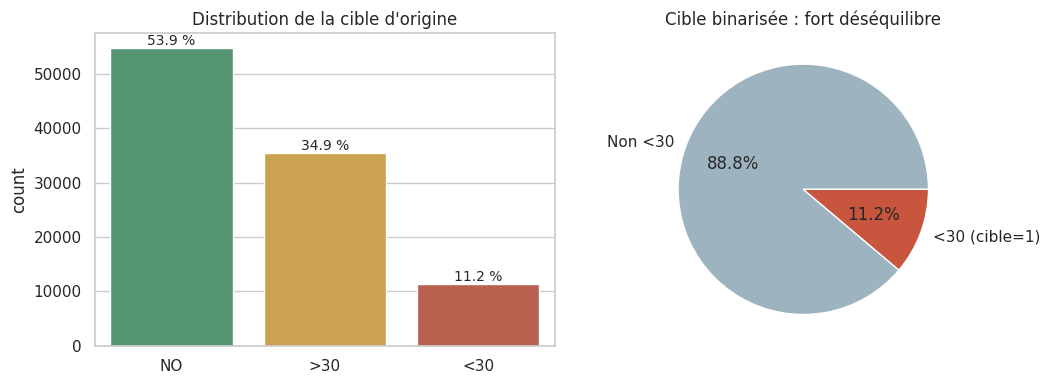

In [8]:
raw["readmit_30"] = (raw.readmitted == "<30").astype(int)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
order = ["NO", ">30", "<30"]
sns.countplot(data=raw, x="readmitted", order=order, palette=["#4C9F70", "#E0A93B", "#C8553D"], ax=ax[0])
for p in ax[0].patches:
    ax[0].annotate(f"{p.get_height()/len(raw)*100:.1f} %", (p.get_x()+p.get_width()/2, p.get_height()),
                   ha="center", va="bottom", fontsize=10)
ax[0].set_title("Distribution de la cible d'origine"); ax[0].set_xlabel("")
raw.readmit_30.value_counts().sort_index().plot.pie(autopct="%1.1f%%", labels=["Non <30", "<30 (cible=1)"],
                                                   colors=["#9DB4C0", "#C8553D"], ax=ax[1], ylabel="")
ax[1].set_title("Cible binarisée : fort déséquilibre")
savefig("01_cible")

### 3.1 Valeurs manquantes

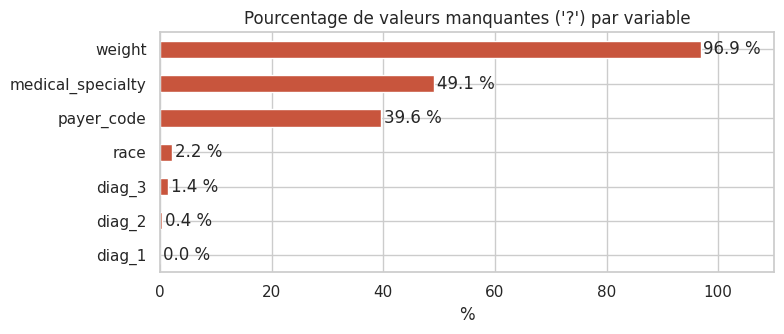

In [9]:
miss = (raw.isna().mean()*100).loc[lambda s: s > 0].sort_values()
fig, ax = plt.subplots(figsize=(8, 3.5))
miss.plot.barh(color="#C8553D", ax=ax)
for i, v in enumerate(miss): ax.text(v+0.5, i, f"{v:.1f} %", va="center")
ax.set_xlim(0, 110); ax.set_title("Pourcentage de valeurs manquantes ('?') par variable"); ax.set_xlabel("%")
savefig("02_manquants")

### 3.2 Distribution des variables numériques

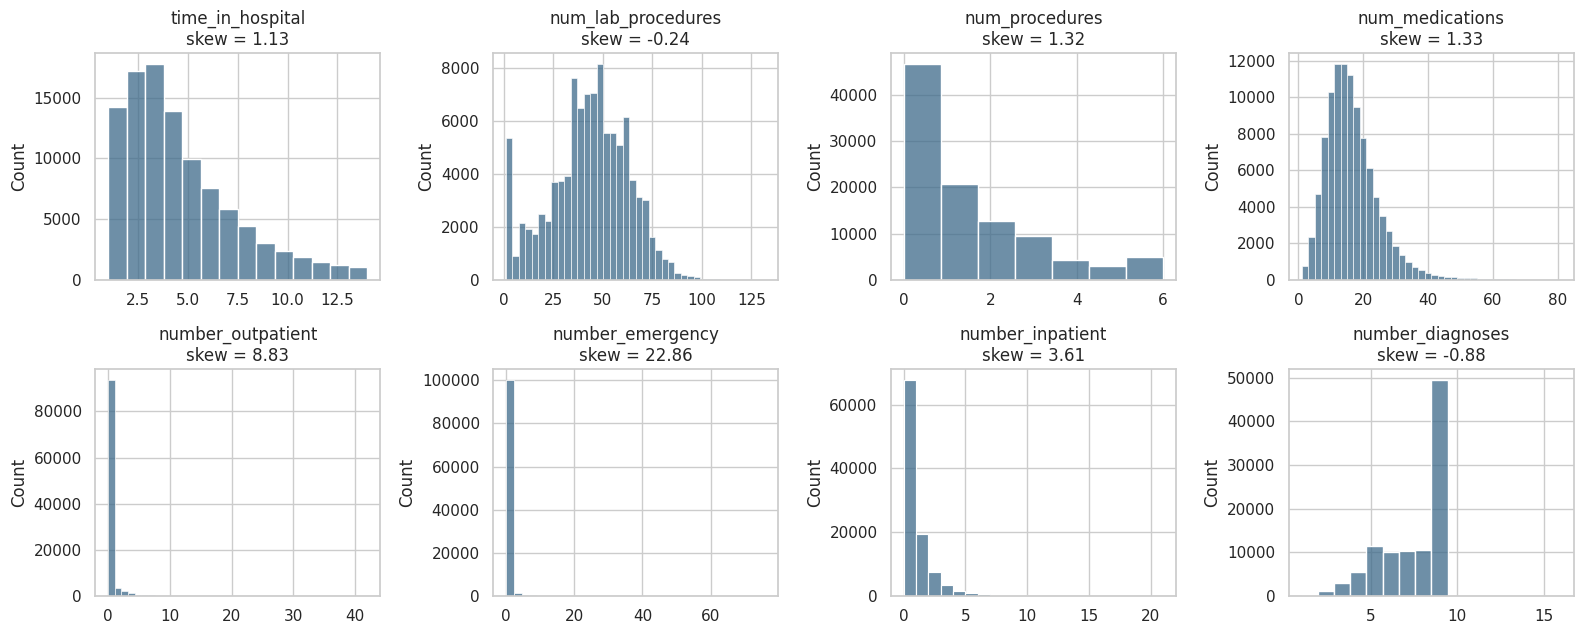

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,101766.0,4.40,2.99,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,101766.0,43.10,19.67,1.0,31.0,44.0,57.0,132.0
num_procedures,101766.0,1.34,1.71,0.0,0.0,1.0,2.0,6.0
num_medications,101766.0,16.02,8.13,1.0,10.0,15.0,20.0,81.0
number_outpatient,101766.0,0.37,1.27,0.0,0.0,0.0,0.0,42.0
number_emergency,101766.0,0.20,0.93,0.0,0.0,0.0,0.0,76.0
number_inpatient,101766.0,0.64,1.26,0.0,0.0,0.0,1.0,21.0
number_diagnoses,101766.0,7.42,1.93,1.0,6.0,8.0,9.0,16.0


In [10]:
NUM_RAW = ["time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications",
           "number_outpatient", "number_emergency", "number_inpatient", "number_diagnoses"]
fig, axes = plt.subplots(2, 4, figsize=(16, 6.5))
for ax, c in zip(axes.ravel(), NUM_RAW):
    sns.histplot(raw[c], bins=min(40, raw[c].nunique()), color="#3D6A8A", ax=ax)
    ax.set_title(f"{c}\nskew = {raw[c].skew():.2f}"); ax.set_xlabel("")
savefig("03_distributions_num")
raw[NUM_RAW].describe().T.round(2)

**Lecture.** Les variables d'historique (`number_outpatient`, `number_emergency`, `number_inpatient`) sont **très asymétriques à droite** (la majorité des patients à 0, quelques-uns à plus de 20-70) ; `num_medications` et `num_lab_procedures` ont des queues longues. `time_in_hospital` (1-14 jours) est plus régulière mais asymétrique. Ces variables nécessiteront un traitement des outliers et une transformation (log).

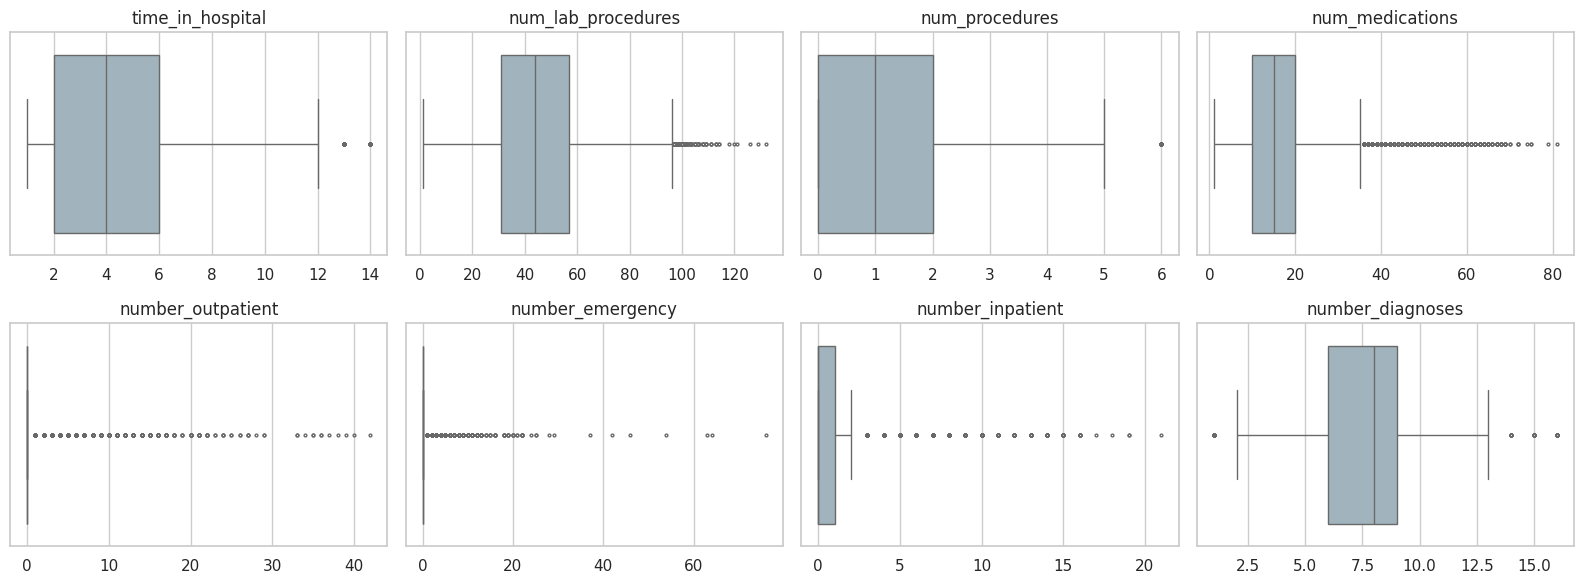

,n_outliers_IQR,%,max,p99
time_in_hospital,2252,2.21,14,14.0
num_lab_procedures,143,0.14,132,85.0
num_procedures,4954,4.87,6,6.0
num_medications,2557,2.51,81,43.0
number_outpatient,16739,16.45,42,5.0
number_emergency,11383,11.19,76,3.0
number_inpatient,7049,6.93,21,6.0
number_diagnoses,281,0.28,16,9.0


In [11]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, c in zip(axes.ravel(), NUM_RAW):
    sns.boxplot(x=raw[c], color="#9DB4C0", fliersize=2, ax=ax); ax.set_title(c); ax.set_xlabel("")
savefig("04_boxplots")

def iqr_outliers(s):
    q1, q3 = s.quantile([.25, .75]); i = q3 - q1
    return ((s < q1-1.5*i) | (s > q3+1.5*i)).sum()
out = pd.DataFrame({"n_outliers_IQR": {c: iqr_outliers(raw[c]) for c in NUM_RAW}})
out["%"] = (out.n_outliers_IQR/len(raw)*100).round(2)
out["max"] = raw[NUM_RAW].max(); out["p99"] = raw[NUM_RAW].quantile(.99)
out

### 3.3 Tendances et relations avec la réadmission

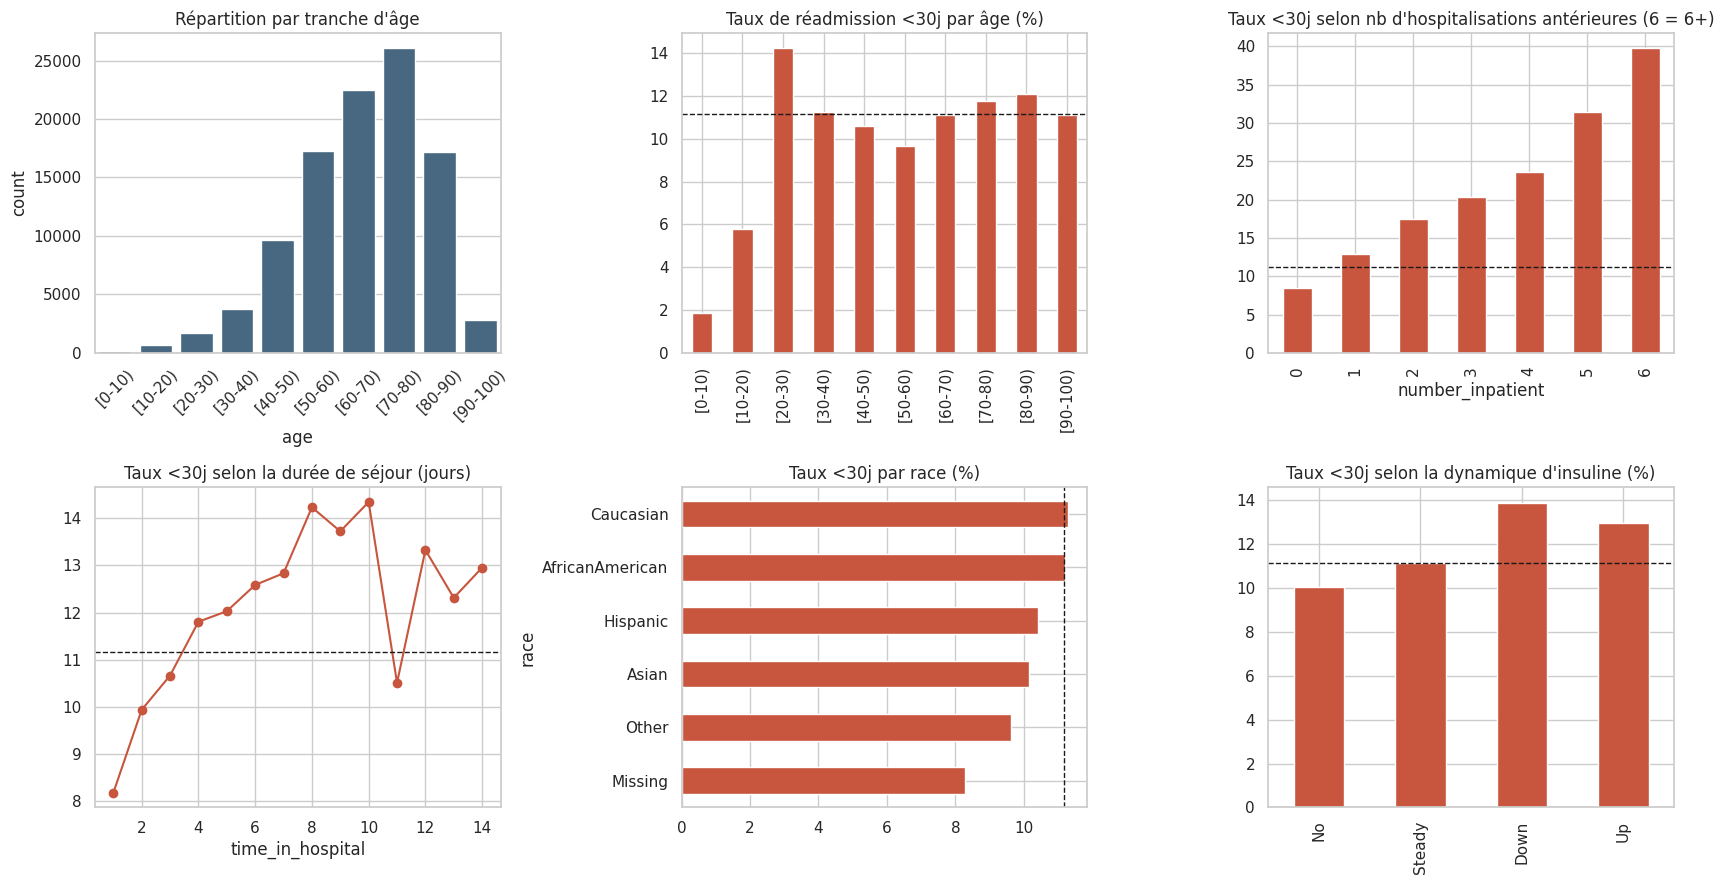

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

# Age
age_order = sorted(raw.age.unique(), key=lambda s: int(s.strip("[(").split("-")[0]))
sns.countplot(data=raw, x="age", order=age_order, color="#3D6A8A", ax=axes[0,0]); axes[0,0].set_title("Répartition par tranche d'âge")
axes[0,0].tick_params(axis="x", rotation=45)
r = raw.groupby("age").readmit_30.mean().reindex(age_order)*100
r.plot.bar(color="#C8553D", ax=axes[0,1]); axes[0,1].set_title("Taux de réadmission <30j par âge (%)"); axes[0,1].axhline(raw.readmit_30.mean()*100, ls="--", c="k", lw=1)
axes[0,1].set_xlabel("")

# Séjours hospitaliers antérieurs
ni = raw.number_inpatient.clip(upper=6)
r = raw.groupby(ni).readmit_30.mean()*100
r.plot.bar(color="#C8553D", ax=axes[0,2]); axes[0,2].set_title("Taux <30j selon nb d'hospitalisations antérieures (6 = 6+)")
axes[0,2].axhline(raw.readmit_30.mean()*100, ls="--", c="k", lw=1); axes[0,2].set_xlabel("number_inpatient")

# Durée de séjour
r = raw.groupby("time_in_hospital").readmit_30.mean()*100
r.plot(marker="o", color="#C8553D", ax=axes[1,0]); axes[1,0].set_title("Taux <30j selon la durée de séjour (jours)")
axes[1,0].axhline(raw.readmit_30.mean()*100, ls="--", c="k", lw=1)

# Race
r = raw.fillna({"race": "Missing"}).groupby("race").readmit_30.agg(["mean", "size"]).sort_values("mean")
(r["mean"]*100).plot.barh(color="#C8553D", ax=axes[1,1]); axes[1,1].set_title("Taux <30j par race (%)"); axes[1,1].axvline(raw.readmit_30.mean()*100, ls="--", c="k", lw=1)

# Insuline
r = raw.groupby("insulin").readmit_30.mean()*100
r.reindex(["No", "Steady", "Down", "Up"]).plot.bar(color="#C8553D", ax=axes[1,2]); axes[1,2].set_title("Taux <30j selon la dynamique d'insuline (%)")
axes[1,2].axhline(raw.readmit_30.mean()*100, ls="--", c="k", lw=1); axes[1,2].set_xlabel("")
savefig("05_tendances")

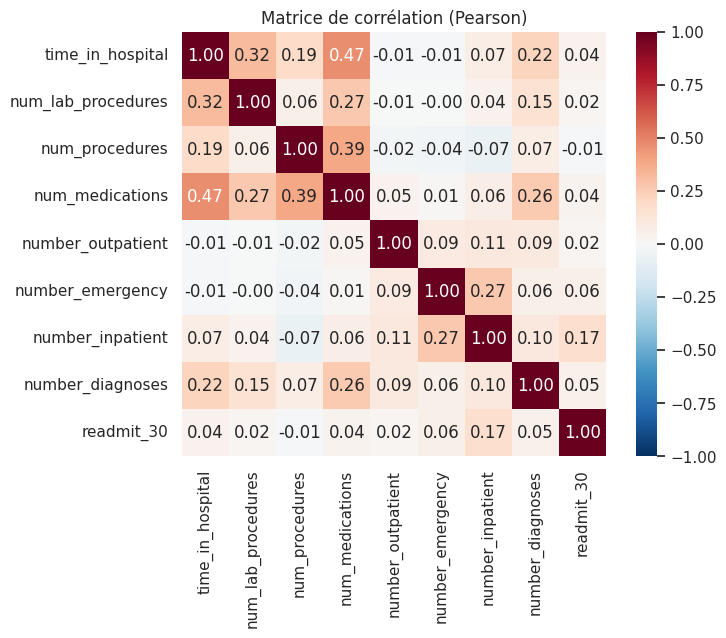

In [13]:
corr_cols = NUM_RAW + ["readmit_30"]
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(raw[corr_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title("Matrice de corrélation (Pearson)")
savefig("06_correlation")

**Lecture.**
- Les corrélations linéaires avec la cible sont **faibles** : la plus forte est `number_inpatient` (r ≈ 0,17), suivie de `number_emergency` (≈ 0,06), les autres sont inférieures à 0,05. Le taux de réadmission passe de ~8 % (aucune hospitalisation antérieure) à ~40 % (6 et plus), une relation nette et monotone. Le problème reste intrinsèquement difficile : on ne doit pas s'attendre à un AUC très élevé.
- Corrélations entre explicatives : `time_in_hospital` ↔ `num_medications` (~0,47) et `time_in_hospital` ↔ `num_lab_procedures` (~0,32) : plus un séjour est long, plus il y a d'actes, ce qui justifiera des variables ramenées *par jour de séjour*.
- **Âge :** le taux est très faible avant 20 ans (≈ 2 % puis 6 %, petits effectifs), puis relativement stable autour de 10-12 % ; il n'y a pas de tendance monotone avec l'âge. **Insuline :** le taux est plus élevé quand la dose est modifiée (`Down` ≈ 14 %, `Up` ≈ 13 %) que sans insuline (≈ 10 %). **Durée de séjour :** le taux augmente de ~8 % (1 jour) à ~12-14 % (≥ 5 jours).

### 3.4 Détection d'anomalies et problèmes de qualité

In [14]:
print("1) Genre invalide :", (raw.gender == "Unknown/Invalid").sum(), "lignes")

dd = ids["discharge_disposition_id"].set_index("discharge_disposition_id").description
EXPIRED_HOSPICE = [11, 13, 14, 19, 20, 21]
n_exp = raw.discharge_disposition_id.isin(EXPIRED_HOSPICE).sum()
print(f"2) Patients décédés ou en hospice à la sortie : {n_exp} séjours -> ne peuvent pas être réadmis")
print("   taux de réadmission <30j pour ces séjours :", round(raw.loc[raw.discharge_disposition_id.isin(EXPIRED_HOSPICE), "readmit_30"].mean()*100, 2), "%")
print("   (contre", round(raw.readmit_30.mean()*100, 2), "% globalement)")

print("\n3) number_diagnoses : valeurs > 9 :", (raw.number_diagnoses > 9).sum(), "lignes (seuls 3 diagnostics sont fournis ; max attendu = 9 dans la collecte d'origine)")

print("\n4) Codes 'inconnus' dans les identifiants (NULL / Not Available / Not Mapped) :")
for col, bad in [("admission_type_id", [5, 6, 8]), ("admission_source_id", [9, 15, 17, 20, 21]), ("discharge_disposition_id", [18, 25, 26])]:
    print(f"   {col}: {raw[col].isin(bad).mean()*100:.1f} %")

print("\n5) Tests de laboratoire : 'None' (non réalisé)")
print("   A1Cresult  non testé :", f"{(raw.A1Cresult=='None').mean()*100:.1f} %", "| max_glu_serum non testé :", f"{(raw.max_glu_serum=='None').mean()*100:.1f} %")

1) Genre invalide : 3 lignes
2) Patients décédés ou en hospice à la sortie : 2423 séjours -> ne peuvent pas être réadmis
   taux de réadmission <30j pour ces séjours : 1.77 %
   (contre 11.16 % globalement)

3) number_diagnoses : valeurs > 9 : 115 lignes (seuls 3 diagnostics sont fournis ; max attendu = 9 dans la collecte d'origine)

4) Codes 'inconnus' dans les identifiants (NULL / Not Available / Not Mapped) :
   admission_type_id: 10.2 %
   admission_source_id: 6.9 %
   discharge_disposition_id: 4.6 %

5) Tests de laboratoire : 'None' (non réalisé)
   A1Cresult  non testé : 83.3 % | max_glu_serum non testé : 94.7 %


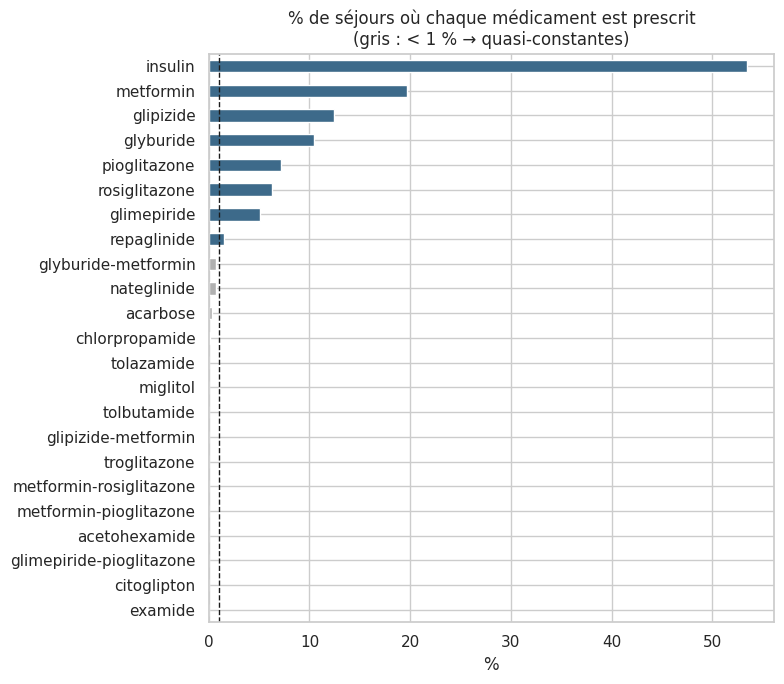

Variables constantes (100% 'No') : ['examide', 'citoglipton']


In [15]:
drug_cols = list(raw.columns[list(raw.columns).index("metformin"): list(raw.columns).index("metformin-pioglitazone")+1])
usage = ((raw[drug_cols] != "No").mean()*100).sort_values()
fig, ax = plt.subplots(figsize=(8, 7))
usage.plot.barh(color=np.where(usage < 1, "#B0B0B0", "#3D6A8A"), ax=ax)
ax.axvline(1, color="k", ls="--", lw=1); ax.set_title("% de séjours où chaque médicament est prescrit\n(gris : < 1 % → quasi-constantes)")
ax.set_xlabel("%")
savefig("07_medicaments")
print("Variables constantes (100% 'No') :", [c for c in drug_cols if raw[c].nunique() == 1])

**Problèmes de qualité identifiés (synthèse)**

| # | Problème | Impact |
|---|---|---|
| 1 | `weight` manquant à 97 %, `payer_code` ~40 %, `medical_specialty` ~49 %, `race` ~2 % | Imputation impossible ou risquée |
| 2 | Plusieurs séjours par patient (≈ 30 % de lignes redondantes) | Non-indépendance → fuite train/test, sur-représentation des gros consommateurs |
| 3 | Séjours terminés par décès ou hospice | Cible non définie (ne peuvent pas être réadmis) |
| 4 | 3 lignes `gender = Unknown/Invalid` | Donnée invalide |
| 5 | Codes `diag_1/2/3` CIM-9 : plusieurs centaines de modalités | Cardinalité trop haute pour un one-hot |
| 6 | Identifiants de admission/discharge avec doublons sémantiques (`NULL`, `Not Mapped`, `Not Available`) | Modalités équivalentes à regrouper |
| 7 | 23 colonnes médicaments dont certaines constantes ou quasi-constantes | Bruit, dimensionnalité inutile |
| 8 | Variables numériques asymétriques avec queues extrêmes | Sensibilité des modèles à distance/linéaires |
| 9 | `number_diagnoses` > 9 | Incohérence avec le protocole de collecte |
| 10 | `None` dans A1C / glucose interprété à tort comme NaN par pandas | Perte d'une information (*non testé*) |
| 11 | Cible déséquilibrée (11 %) | Nécessite métriques et pondération adaptées |

## 4. Data Preparation

Chaque étape est **justifiée** et le nombre de lignes est tracé pour mesurer l'impact des suppressions.

### 4.1 Filtrage des lignes (validité et indépendance)

In [16]:
log = []
def step(name, d): log.append({"étape": name, "lignes": len(d), "patients": d.patient_nbr.nunique()})

df = raw.copy()
step("Données brutes", df)

# (a) Genre invalide : 3 lignes, non imputables de façon fiable -> suppression
df = df[df.gender != "Unknown/Invalid"]
step("Suppression gender invalide", df)

# (b) Décès / hospice : la réadmission n'est pas définie pour ces patients
df = df[~df.discharge_disposition_id.isin(EXPIRED_HOSPICE)]
step("Suppression décès / hospice", df)

# (c) Un seul séjour par patient : on garde le PREMIER séjour (encounter_id croissant ~ ordre chronologique)
df = df.sort_values("encounter_id").drop_duplicates("patient_nbr", keep="first")
step("Un séjour (le 1er) par patient", df)

pd.DataFrame(log)

,étape,lignes,patients
0,Données brutes,101766,71518
1,Suppression gender invalide,101763,71515
2,Suppression décès / hospice,99340,69987
3,Un séjour (le 1er) par patient,69987,69987


**Justifications**
- **(a)** Trois lignes seulement : supprimer est moins risqué qu'inventer un genre.
- **(b)** Un patient décédé ou en hospice ne peut pas être réadmis. Les garder fausserait la cible (taux de `<30` artificiellement bas) et le modèle apprendrait « décès ⇒ pas de réadmission ».
- **(c)** Plusieurs séjours d'un même patient sont corrélés. Les garder crée (i) une **fuite** si un même patient est à la fois dans le train et le test, et (ii) un poids excessif des patients très hospitalisés. On garde le premier séjour : cela correspond aussi à la logique « prédire à la sortie d'un séjour ». Le prix à payer est une perte de ~31 % des lignes (101 766 → 69 987) ; c'est acceptable au vu des ~70 000 lignes restantes. **Effet de bord à connaître :** le taux de positifs passe de 11,2 % à ~9,0 % (le premier séjour est moins souvent suivi d'une réadmission rapide que les séjours des patients très récurrents), et les variables d'historique ont des valeurs plus faibles.

### 4.2 Valeurs manquantes

| Variable | Manquants | Décision | Justification |
|---|---|---|---|
| `weight` | ~97 % | **Suppression** | Aucune imputation crédible ; l'information est quasi absente |
| `payer_code` | ~40 % | Regroupement des modalités rares + catégorie `Unknown` | Le manquant est peut-être informatif (type d'assurance) ; on évite de l'imputer |
| `medical_specialty` | ~49 % | Top-8 + `Other` + `Unknown` | Haute cardinalité + manquant massif |
| `race` | ~2 % | Catégorie `Unknown` | Faible proportion ; la catégorie reste exploitable |
| `diag_1/2/3` | <2 % | Catégorie `Missing` après regroupement | Un diagnostic absent (surtout `diag_3`) a un sens : moins de comorbidités |
| `A1Cresult`, `max_glu_serum` | `None` = non testé | Modalité `Not tested` | Le test non réalisé est une information clinique |

Une imputation par la moyenne/mode ou par KNN aurait été injustifiée ici : les variables sont catégorielles, les manquants sont majoritairement *non aléatoires* (MNAR) et leur présence même est informative.

In [17]:
df = df.drop(columns=["weight"])

# race
df["race"] = df["race"].fillna("Unknown")

# payer_code : 5 modalités principales + Other + Unknown
top_payer = df.payer_code.value_counts().head(5).index
df["payer_group"] = np.where(df.payer_code.isna(), "Unknown", np.where(df.payer_code.isin(top_payer), df.payer_code, "Other"))

# medical_specialty : 8 principales + Other + Unknown
top_spec = df.medical_specialty.value_counts().head(8).index
df["specialty_group"] = np.where(df.medical_specialty.isna(), "Unknown", np.where(df.medical_specialty.isin(top_spec), df.medical_specialty, "Other"))

# Tests de laboratoire : 'None' -> 'Not tested'
for c in ["A1Cresult", "max_glu_serum"]:
    df[c] = df[c].replace("None", "Not tested")

print("Specialités conservées :", list(top_spec))
print("Payer conservés        :", list(top_payer))
df[["race", "payer_group", "specialty_group", "A1Cresult", "max_glu_serum"]].isna().sum()

Specialités conservées : ['InternalMedicine', 'Family/GeneralPractice', 'Emergency/Trauma', 'Cardiology', 'Surgery-General', 'Orthopedics', 'Orthopedics-Reconstructive', 'Radiologist']
Payer conservés        : ['MC', 'HM', 'BC', 'SP', 'MD']


,0
race,0
payer_group,0
specialty_group,0
A1Cresult,0
max_glu_serum,0


### 4.3 Variables catégorielles à haute cardinalité

**Diagnostics `diag_1/2/3` (codes CIM-9).** Plusieurs centaines de codes, la plupart rares : un one-hot créerait des centaines de colonnes quasi vides (malédiction de la dimension, surapprentissage). On regroupe en **9 familles cliniques** (regroupement de l'étude originale de Strack et al.) : Diabète, Circulatoire, Respiratoire, Digestif, Traumatismes, Musculo-squelettique, Génito-urinaire, Tumeurs, Autres.

**Identifiants `admission_type_id`, `admission_source_id`, `discharge_disposition_id`.** Ce sont des **codes**, pas des nombres : les traiter comme numériques introduirait un ordre artificiel (« 7 > 1 »). On les décode avec `IDS_mapping.csv` et on regroupe les modalités sémantiquement équivalentes (`NULL`, `Not Available`, `Not Mapped` → `Unknown`).

Nb de codes distincts avant regroupement : 694 (diag_1), 723 (diag_2), 756 (diag_3)


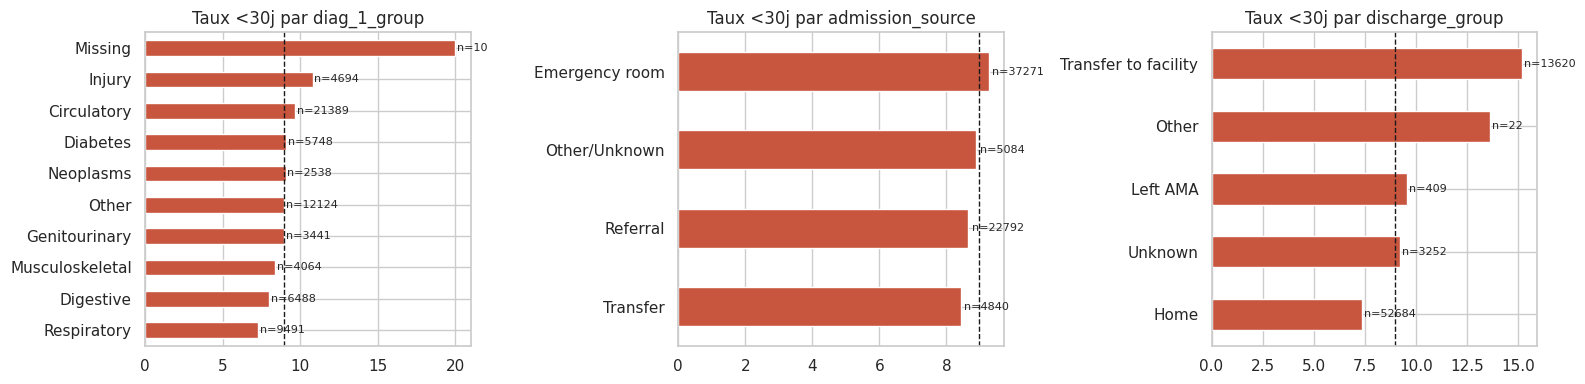

In [18]:
print("Nb de codes distincts avant regroupement :", df.diag_1.nunique(), "(diag_1),", df.diag_2.nunique(), "(diag_2),", df.diag_3.nunique(), "(diag_3)")

def icd9_group(code):
    if pd.isna(code): return "Missing"
    if str(code).startswith(("V", "E")): return "Other"
    c = float(code)
    if 250 <= c < 251: return "Diabetes"
    if 390 <= c <= 459 or int(c) == 785: return "Circulatory"
    if 460 <= c <= 519 or int(c) == 786: return "Respiratory"
    if 520 <= c <= 579 or int(c) == 787: return "Digestive"
    if 800 <= c <= 999: return "Injury"
    if 710 <= c <= 739: return "Musculoskeletal"
    if 580 <= c <= 629 or int(c) == 788: return "Genitourinary"
    if 140 <= c <= 239: return "Neoplasms"
    return "Other"

for i in (1, 2, 3):
    df[f"diag_{i}_group"] = df[f"diag_{i}"].map(icd9_group)

# Admission type
df["admission_type"] = df.admission_type_id.map(lambda x: "Emergency/Urgent/Trauma" if x in (1, 2, 7) else "Elective" if x == 3 else "Newborn" if x == 4 else "Unknown")
# Admission source
def adm_src(x):
    if x in (1, 2, 3): return "Referral"
    if x == 7: return "Emergency room"
    if x in (4, 5, 6, 10, 18, 22, 25, 26): return "Transfer"
    return "Other/Unknown"
df["admission_source"] = df.admission_source_id.map(adm_src)
# Discharge
def dis(x):
    if x in (1, 6, 8): return "Home"
    if x == 7: return "Left AMA"
    if x in (18, 25, 26): return "Unknown"
    if x in (12, 9, 17, 16): return "Other"
    return "Transfer to facility"
df["discharge_group"] = df.discharge_disposition_id.map(dis)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, c in zip(axes, ["diag_1_group", "admission_source", "discharge_group"]):
    r = df.groupby(c).readmit_30.agg(["mean", "size"]).sort_values("mean")
    (r["mean"]*100).plot.barh(color="#C8553D", ax=ax)
    for i, (m, n) in enumerate(zip(r["mean"], r["size"])): ax.text(m*100+0.1, i, f"n={n}", va="center", fontsize=8)
    ax.set_title(f"Taux <30j par {c}"); ax.set_ylabel(""); ax.axvline(df.readmit_30.mean()*100, ls="--", c="k", lw=1)
savefig("08_groupes_categoriels")

**Vérification.** Le regroupement conserve du signal, très inégal selon la variable : la **destination à la sortie** discrimine fortement (retour à domicile ≈ 7 % vs transfert vers un établissement ≈ 15 %), alors que la famille du diagnostic principal ne fait varier le taux que modestement (≈ 7 % en respiratoire à ≈ 11 % en traumatologie). La modalité `Missing` de `diag_1` (≈ 20 %) repose sur très peu de lignes et doit être lue avec prudence. La modalité `Other` de `discharge_group` est quasi vide (22 lignes) ; `min_frequency=20` dans l'encodeur évite de créer une colonne pour des modalités aussi rares.

### 4.4 Variables de médicaments (23 colonnes)

- `examide` et `citoglipton` sont **constantes** (toujours `No`) → aucune information, suppression.
- Plusieurs autres sont prescrites dans **moins de 1 %** des séjours : pour un modèle, ce sont des colonnes quasi vides (surapprentissage).
- **Choix :** (1) on garde l'indicateur « prescrit / non prescrit » pour les médicaments utilisés dans ≥ 1 % des séjours, (2) on garde `insulin` sous ses 4 modalités (c'est le médicament central, sa **dynamique** `Up/Down` est cliniquement informative), (3) on résume le reste par deux variables agrégées : `n_drugs` (nombre de médicaments actifs) et `n_drug_changes` (nombre de changements de dose).

In [19]:
usage = (df[drug_cols] != "No").mean()
common = [c for c in usage[usage >= 0.01].index if c != "insulin"]
print("Médicaments conservés (>=1 % d'usage) :", common)
print("Médicaments supprimés (constants/rares) :", [c for c in drug_cols if c not in common and c != "insulin"])

df["n_drugs"] = (df[drug_cols] != "No").sum(axis=1)
df["n_drug_changes"] = df[drug_cols].isin(["Up", "Down"]).sum(axis=1)
for c in common:
    df[f"drug_{c}"] = (df[c] != "No").astype(int)
df["change_flag"] = (df["change"] == "Ch").astype(int)
df["diabetesMed_flag"] = (df["diabetesMed"] == "Yes").astype(int)

Médicaments conservés (>=1 % d'usage) : ['metformin', 'repaglinide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone']
Médicaments supprimés (constants/rares) : ['nateglinide', 'chlorpropamide', 'acetohexamide', 'tolbutamide', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']


### 4.5 Valeurs aberrantes (outliers)

**Diagnostic.** La règle IQR signale plusieurs % d'outliers sur `num_medications`, `number_outpatient`, `number_emergency`… Toutefois, ces valeurs ne sont **pas des erreurs de saisie** : un patient avec 40 passages aux urgences ou 80 médicaments est clinique­ment plausible et fait partie des cas les plus à risque. **Les supprimer retirerait précisément les patients que l'on veut détecter.**

**Choix : winsorisation au 99ᵉ percentile** (plafonnement) pour les variables de comptage à queue extrême. On conserve toutes les lignes, mais on limite l'influence des valeurs extrêmes sur la moyenne/variance (utile pour K-Means et la régression logistique, sensibles à l'échelle). Les modèles à base d'arbres y sont peu sensibles, mais une même préparation permet de comparer les modèles équitablement.

**Cas particulier :** `number_diagnoses` > 9 est incohérent avec le protocole de collecte (au plus 9 diagnostics) → plafonné à 9.

In [20]:
WINS_COLS = ["num_lab_procedures", "num_medications", "number_outpatient", "number_emergency", "number_inpatient"]
caps = {c: df[c].quantile(0.99) for c in WINS_COLS}
before = df[WINS_COLS].copy()
for c, cap in caps.items():
    df[c] = df[c].clip(upper=cap)
df["number_diagnoses"] = df["number_diagnoses"].clip(upper=9)

pd.DataFrame({"cap (p99)": pd.Series(caps), "max avant": before.max(), "max après": df[WINS_COLS].max(),
              "lignes plafonnées": (before > pd.Series(caps)).sum()})

,cap (p99),max avant,max après,lignes plafonnées
num_lab_procedures,85.0,132,85,633
num_medications,44.0,81,44,683
number_outpatient,4.0,42,4,690
number_emergency,2.0,42,2,429
number_inpatient,3.0,12,3,433


### 4.6 Feature engineering

| Nouvelle variable | Définition | Intérêt |
|---|---|---|
| `age_num` | Milieu de la tranche d'âge (`[60-70)` → 65) | Variable **ordinale** convertie en numérique : conserve l'ordre et réduit 10 colonnes one-hot à 1 |
| `total_prior_visits` | `outpatient + emergency + inpatient` (année précédente) | Mesure globale d'utilisation du système de soins |
| `lab_per_day` | `num_lab_procedures / time_in_hospital` | Intensité de la surveillance, indépendante de la durée |
| `meds_per_day` | `num_medications / time_in_hospital` | Intensité du traitement, décorrèle de la durée |
| `n_diabetes_diag` | Nb de diagnostics (parmi 3) du groupe *Diabète* | Poids de la maladie dans le tableau clinique |
| `a1c_high` | `A1Cresult` ∈ {`>7`, `>8`} | Mauvais contrôle glycémique |
| `a1c_tested`, `glu_tested` | Test réalisé ou non | La décision de tester reflète la gravité perçue |
| `n_drugs`, `n_drug_changes` | Cf. 4.4 | Complexité thérapeutique |
| `gender_male` | Encodage binaire | |

In [21]:
age_map = {f"[{a}-{a+10})": a + 5 for a in range(0, 100, 10)}
df["age_num"] = df["age"].map(age_map)
assert df["age_num"].notna().all()

df["total_prior_visits"] = df.number_outpatient + df.number_emergency + df.number_inpatient
df["lab_per_day"] = df.num_lab_procedures / df.time_in_hospital
df["meds_per_day"] = df.num_medications / df.time_in_hospital
df["n_diabetes_diag"] = sum((df[f"diag_{i}_group"] == "Diabetes").astype(int) for i in (1, 2, 3))
df["a1c_tested"] = (df.A1Cresult != "Not tested").astype(int)
df["a1c_high"] = df.A1Cresult.isin([">7", ">8"]).astype(int)
df["glu_tested"] = (df.max_glu_serum != "Not tested").astype(int)
df["gender_male"] = (df.gender == "Male").astype(int)

### 4.7 Distribution des variables numériques : asymétrie et transformation log

Les variables de comptage restent asymétriques après winsorisation. On applique **`log1p(x) = ln(1 + x)`** (défini en 0, contrairement à `ln`) aux variables dont l'asymétrie (|skew|) dépasse 1. Ce choix est préférable à Box-Cox (nécessite des valeurs > 0) et à la racine carrée (compression moins forte). **Limite :** pour les variables de comptage très concentrées sur 0 (`number_outpatient`, `number_emergency`, `number_inpatient`), le log réduit l'asymétrie sans la supprimer (skew ≈ 3,6 → 2,8-3,6), car la distribution est « zéro-gonflée » ; c'est acceptable pour des modèles d'arbres, et la standardisation reste utile pour la régression logistique. Le log est appliqué **dans le pipeline** de modélisation (§5-6) : le fichier nettoyé garde les valeurs d'origine, plus lisibles.

In [22]:
NUM_FEATS = ["age_num", "time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications",
             "number_outpatient", "number_emergency", "number_inpatient", "number_diagnoses",
             "total_prior_visits", "n_drugs", "n_drug_changes", "lab_per_day", "meds_per_day", "n_diabetes_diag"]
skew = df[NUM_FEATS].skew()
SKEWED = skew[skew.abs() > 1].index.tolist()
skew_after = np.log1p(df[SKEWED]).skew()
print("Variables transformées en log1p :", SKEWED)
pd.DataFrame({"skew avant": skew[SKEWED], "skew après log1p": skew_after}).round(2)

Variables transformées en log1p : ['time_in_hospital', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'total_prior_visits', 'n_drug_changes', 'lab_per_day', 'meds_per_day']


,skew avant,skew après log1p
time_in_hospital,1.18,0.14
num_procedures,1.23,0.45
num_medications,1.06,-0.50
number_outpatient,3.55,2.78
number_emergency,4.06,3.61
number_inpatient,3.60,2.86
total_prior_visits,2.67,1.67
n_drug_changes,1.60,1.30
lab_per_day,1.77,-0.48
meds_per_day,2.20,0.44


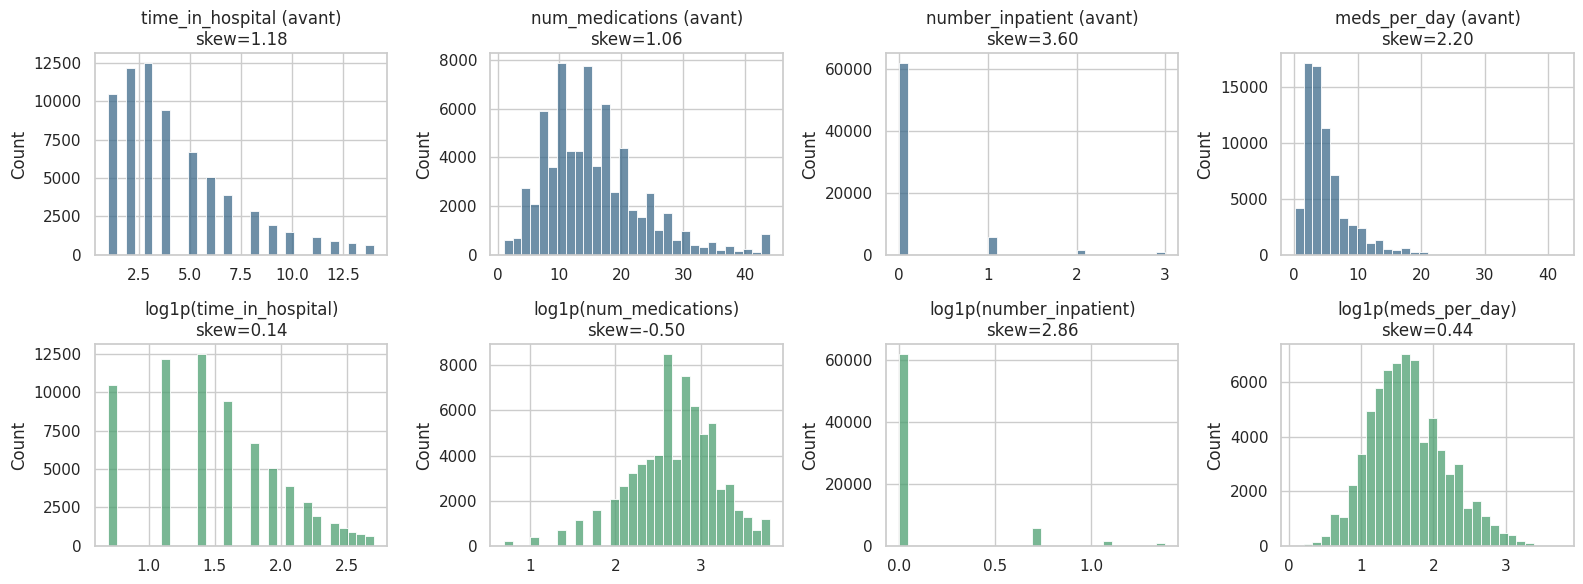

In [23]:
show = ["time_in_hospital", "num_medications", "number_inpatient", "meds_per_day"]
fig, axes = plt.subplots(2, len(show), figsize=(4*len(show), 6))
for j, c in enumerate(show):
    sns.histplot(df[c], bins=30, color="#3D6A8A", ax=axes[0, j]); axes[0, j].set_title(f"{c} (avant)\nskew={df[c].skew():.2f}")
    sns.histplot(np.log1p(df[c]), bins=30, color="#4C9F70", ax=axes[1, j]); axes[1, j].set_title(f"log1p({c})\nskew={np.log1p(df[c]).skew():.2f}")
    for ax in axes[:, j]: ax.set_xlabel("")
savefig("09_log_transform")

### 4.8 Encodage, mise à l'échelle et jeu de données final

- **Variables nominales** (`race`, `admission_*`, `discharge_group`, `payer_group`, `specialty_group`, `diag_*_group`, `insulin`, `A1Cresult`, `max_glu_serum`) → **One-Hot Encoding** (pas d'ordre naturel ; peu de modalités après regroupement). Pas de *label encoding*, qui imposerait un ordre artificiel.
- **Variables numériques** → `StandardScaler` (moyenne 0, écart-type 1), indispensable pour K-Means (distance euclidienne) et la régression logistique. Les arbres n'en ont pas besoin mais ne sont pas pénalisés.
- **Toutes ces étapes (log, scaling, encodage) sont ajustées uniquement sur le jeu d'entraînement dans des `Pipeline`** (§6), afin d'éviter toute fuite de données (*data leakage*) vers le test.

Le fichier nettoyé exporté ci-dessous contient les données **nettoyées, regroupées et enrichies** (lisibles) ; un second fichier « model-ready » (encodé et standardisé) est aussi fourni.

In [24]:
CAT_FEATS = ["race", "admission_type", "admission_source", "discharge_group", "payer_group", "specialty_group",
             "diag_1_group", "diag_2_group", "diag_3_group", "A1Cresult", "max_glu_serum", "insulin"]
BIN_FEATS = ["gender_male", "change_flag", "diabetesMed_flag", "a1c_tested", "a1c_high", "glu_tested"] + [f"drug_{c}" for c in common]
FEATURES = NUM_FEATS + BIN_FEATS + CAT_FEATS
TARGET = "readmit_30"

clean = df[["encounter_id", "patient_nbr"] + FEATURES + ["readmitted", TARGET]].reset_index(drop=True)
assert clean[FEATURES].isna().sum().sum() == 0, "Il reste des valeurs manquantes"
print("Jeu de données nettoyé :", clean.shape, "| manquants restants :", int(clean.isna().sum().sum()))
print(f"Taux de positifs (<30 jours) : {clean[TARGET].mean()*100:.2f} %")

clean.to_csv(os.path.join(OUT_DIR, "diabetic_data_clean.csv"), index=False)
clean.head()

Jeu de données nettoyé : (69987, 44) | manquants restants : 0
Taux de positifs (<30 jours) : 8.98 %


,encounter_id,patient_nbr,age_num,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,payer_group,specialty_group,diag_1_group,diag_2_group,diag_3_group,A1Cresult,max_glu_serum,insulin,readmitted,readmit_30
0,12522,48330783,85,13,68,2,28,0,0,0,...,Unknown,Unknown,Circulatory,Circulatory,Other,Not tested,Not tested,Steady,NO,0
1,15738,63555939,95,12,33,3,18,0,0,0,...,Unknown,InternalMedicine,Circulatory,Neoplasms,Respiratory,Not tested,Not tested,Steady,NO,0
2,16680,42519267,45,1,51,0,8,0,0,0,...,Unknown,Unknown,Neoplasms,Neoplasms,Diabetes,Not tested,Not tested,Steady,NO,0
3,28236,89869032,45,9,47,2,17,0,0,0,...,Unknown,Unknown,Diabetes,Circulatory,Injury,Not tested,Not tested,Steady,>30,0
4,35754,82637451,55,3,31,6,16,0,0,0,...,Unknown,Unknown,Circulatory,Circulatory,Diabetes,Not tested,Not tested,Steady,>30,0


In [25]:
# Taille du travail de nettoyage
pd.DataFrame(log)

,étape,lignes,patients
0,Données brutes,101766,71518
1,Suppression gender invalide,101763,71515
2,Suppression décès / hospice,99340,69987
3,Un séjour (le 1er) par patient,69987,69987


## 5. Segmentation (clustering)

**Problématique.** Identifier des *profils de séjours* selon l'intensité de la prise en charge, l'âge, l'historique d'hospitalisations et la complexité thérapeutique, puis vérifier s'ils ont des taux de réadmission différents.

**Choix des variables.** Uniquement des **variables numériques** de lourdeur clinique et d'historique (K-Means repose sur la distance euclidienne, inadaptée aux variables catégorielles). La cible `readmit_30` n'est **pas** utilisée pour le clustering : elle sert seulement ensuite à *interpréter* les segments.

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score

CLUST_FEATS = ["age_num", "time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications",
               "number_diagnoses", "total_prior_visits", "n_drugs", "n_drug_changes"]
Xc = clean[CLUST_FEATS].astype(float).copy()
for c in CLUST_FEATS:
    if c in SKEWED: Xc[c] = np.log1p(Xc[c])
Xc_s = StandardScaler().fit_transform(Xc)
print("Matrice de clustering :", Xc_s.shape, "| log1p appliqué à :", [c for c in CLUST_FEATS if c in SKEWED])

Matrice de clustering : (69987, 9) | log1p appliqué à : ['time_in_hospital', 'num_procedures', 'num_medications', 'total_prior_visits', 'n_drug_changes']


### 5.1 Choix du nombre de clusters *k*
Trois critères sont combinés : **inertie** (méthode du coude), **coefficient de silhouette** (cohésion/séparation, plus grand = mieux), **indice de Davies-Bouldin** (plus petit = mieux). La silhouette est calculée sur un échantillon de 10 000 points pour limiter le temps de calcul.

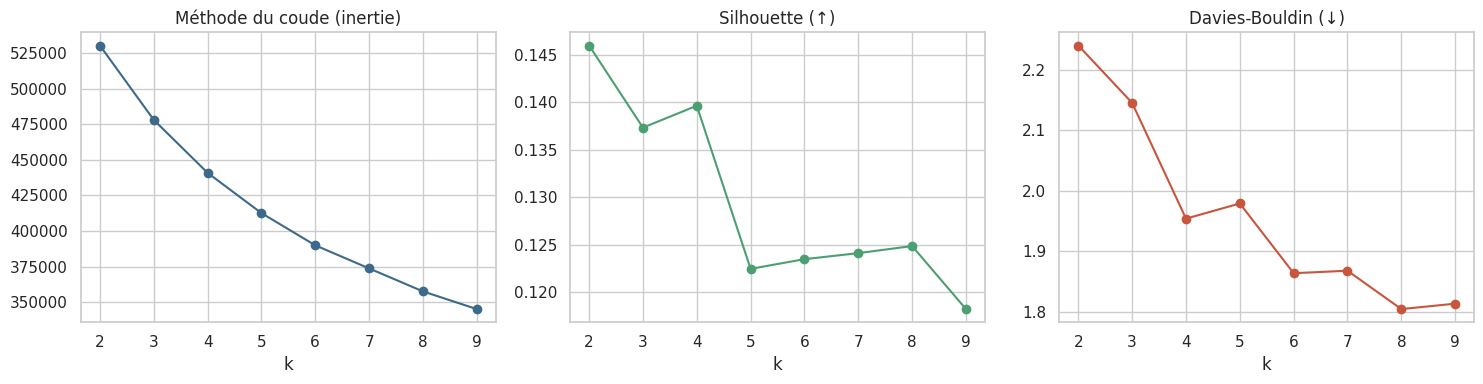

,inertie,silhouette,davies_bouldin,calinski_harabasz
k,,,,
2,530141.485,0.146,2.241,13167.126
3,478032.502,0.137,2.146,11115.527
4,440879.360,0.140,1.954,10000.526
5,412681.605,0.122,1.979,9208.222
6,390079.356,0.123,1.864,8604.277
7,373876.849,0.124,1.868,7986.299
8,357778.919,0.125,1.804,7603.136
9,345371.851,0.118,1.813,7205.841


In [27]:
ks = range(2, 10)
res = []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(Xc_s)
    res.append({"k": k, "inertie": km.inertia_,
                "silhouette": silhouette_score(Xc_s, km.labels_, sample_size=10000, random_state=RANDOM_STATE),
                "davies_bouldin": davies_bouldin_score(Xc_s, km.labels_),
                "calinski_harabasz": calinski_harabasz_score(Xc_s, km.labels_)})
res = pd.DataFrame(res).set_index("k")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
res.inertie.plot(marker="o", ax=axes[0], color="#3D6A8A"); axes[0].set_title("Méthode du coude (inertie)")
res.silhouette.plot(marker="o", ax=axes[1], color="#4C9F70"); axes[1].set_title("Silhouette (↑)")
res.davies_bouldin.plot(marker="o", ax=axes[2], color="#C8553D"); axes[2].set_title("Davies-Bouldin (↓)")
savefig("10_choix_k")
res.round(3)

In [28]:
# k = 2 sépare souvent seulement « séjours courts / longs » et a peu d'intérêt métier : on retient le meilleur k >= 3 (silhouette)
K_FINAL = int(res.loc[3:6, "silhouette"].idxmax())
print("k retenu :", K_FINAL)
km = KMeans(n_clusters=K_FINAL, n_init=20, random_state=RANDOM_STATE).fit(Xc_s)
clean["cluster"] = km.labels_
print(clean.cluster.value_counts().sort_index().to_frame("n").assign(pct=lambda d: (d.n/len(clean)*100).round(1)))

k retenu : 4
             n   pct
cluster             
0        11397  16.3
1        22588  32.3
2        22485  32.1
3        13517  19.3


### 5.2 Visualisation (ACP) et validation de la méthode

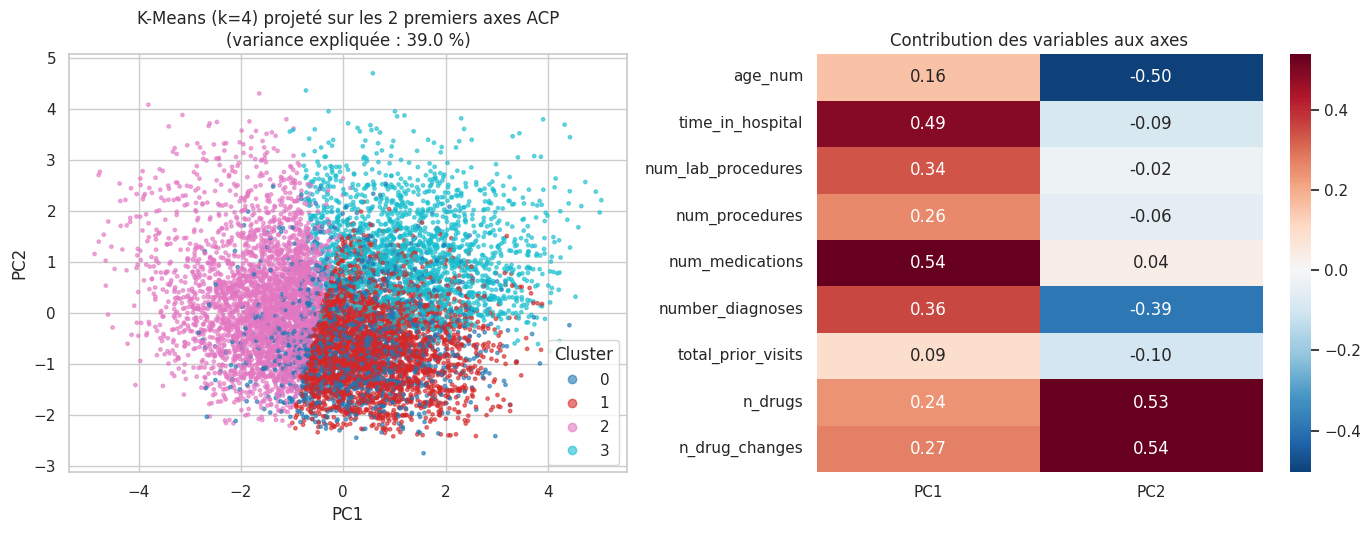

In [29]:
pca = PCA(n_components=2, random_state=RANDOM_STATE).fit(Xc_s)
Z = pca.transform(Xc_s)
idx = np.random.RandomState(RANDOM_STATE).choice(len(Z), 10000, replace=False)
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
sc = ax[0].scatter(Z[idx, 0], Z[idx, 1], c=clean.cluster.values[idx], cmap="tab10", s=6, alpha=.6)
ax[0].set_title(f"K-Means (k={K_FINAL}) projeté sur les 2 premiers axes ACP\n(variance expliquée : {pca.explained_variance_ratio_.sum()*100:.1f} %)")
ax[0].set_xlabel("PC1"); ax[0].set_ylabel("PC2"); ax[0].legend(*sc.legend_elements(), title="Cluster")
load = pd.DataFrame(pca.components_.T, index=CLUST_FEATS, columns=["PC1", "PC2"])
sns.heatmap(load, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax[1]); ax[1].set_title("Contribution des variables aux axes")
savefig("11_acp_clusters")

In [30]:
# Validation croisée : (1) stabilité selon l'initialisation, (2) comparaison avec une classification hiérarchique (Ward)
labs = [KMeans(n_clusters=K_FINAL, n_init=1, random_state=s).fit_predict(Xc_s) for s in range(5)]
ari_seeds = np.mean([adjusted_rand_score(labs[0], l) for l in labs[1:]])

sub = np.random.RandomState(0).choice(len(Xc_s), 6000, replace=False)
hc = AgglomerativeClustering(n_clusters=K_FINAL, linkage="ward").fit_predict(Xc_s[sub])
ari_hc = adjusted_rand_score(clean.cluster.values[sub], hc)
sil_hc = silhouette_score(Xc_s[sub], hc); sil_km = silhouette_score(Xc_s[sub], clean.cluster.values[sub])
print(f"Stabilité K-Means (ARI moyen entre 5 initialisations) : {ari_seeds:.3f}")
print(f"Silhouette K-Means = {sil_km:.3f} | Ward = {sil_hc:.3f} | ARI K-Means vs Ward = {ari_hc:.3f}")

Stabilité K-Means (ARI moyen entre 5 initialisations) : 0.742
Silhouette K-Means = 0.138 | Ward = 0.102 | ARI K-Means vs Ward = 0.493


### 5.3 Profil et interprétation des segments

In [31]:
prof = clean.groupby("cluster")[CLUST_FEATS].mean()
prof["taille"] = clean.cluster.value_counts().sort_index()
prof["% réadmis <30j"] = clean.groupby("cluster")[TARGET].mean()*100
prof.round(2)

,age_num,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,total_prior_visits,n_drugs,n_drug_changes,taille,% réadmis <30j
cluster,,,,,,,,,,,
0,67.89,3.96,42.94,1.10,15.48,7.91,2.35,1.18,0.16,11397,12.20
1,69.87,5.57,48.33,1.93,18.52,7.98,0.07,1.11,0.00,22588,9.49
2,59.90,2.28,32.93,0.92,9.80,5.76,0.11,0.93,0.09,22485,6.27
3,65.19,5.68,49.94,1.69,20.39,7.78,0.29,1.77,1.08,13517,9.93


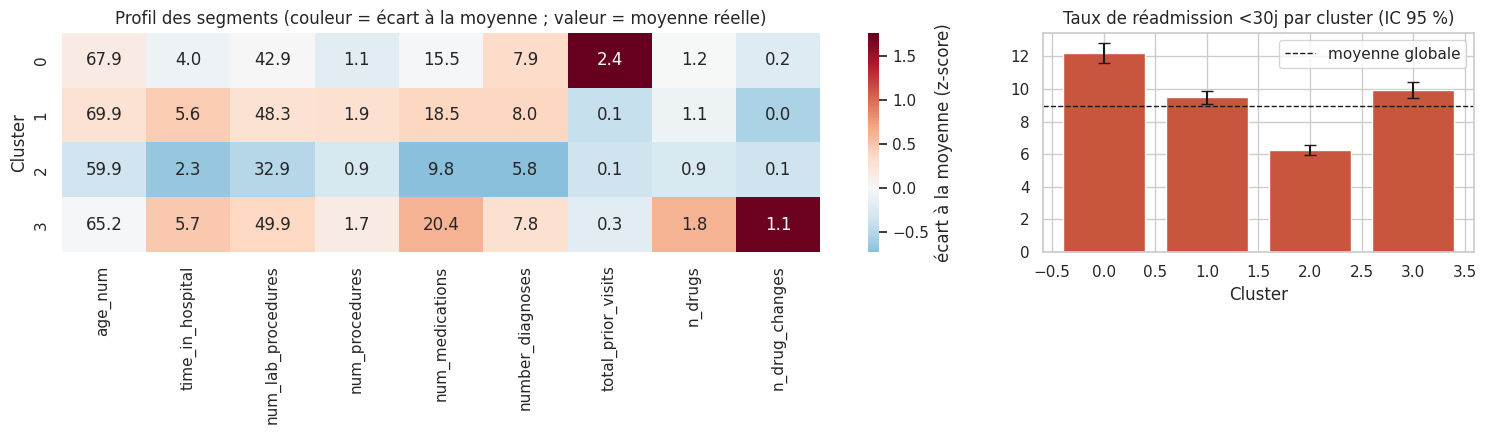

Chi² = 369.6, p-value = 8.66e-80


In [32]:
z = (prof[CLUST_FEATS] - clean[CLUST_FEATS].mean()) / clean[CLUST_FEATS].std()
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5), gridspec_kw={"width_ratios": [2.2, 1]})
sns.heatmap(z, annot=prof[CLUST_FEATS].round(1), fmt="", cmap="RdBu_r", center=0, ax=ax[0], cbar_kws={"label": "écart à la moyenne (z-score)"})
ax[0].set_title("Profil des segments (couleur = écart à la moyenne ; valeur = moyenne réelle)"); ax[0].set_ylabel("Cluster")

rate = clean.groupby("cluster")[TARGET].agg(["mean", "sum", "size"])
ci = 1.96*np.sqrt(rate["mean"]*(1-rate["mean"])/rate["size"])
ax[1].bar(rate.index, rate["mean"]*100, yerr=ci*100, color="#C8553D", capsize=4)
ax[1].axhline(clean[TARGET].mean()*100, ls="--", c="k", lw=1, label="moyenne globale")
ax[1].set_title("Taux de réadmission <30j par cluster (IC 95 %)"); ax[1].set_xlabel("Cluster"); ax[1].legend()
savefig("12_profils_clusters")

# Test du chi² : le risque de réadmission diffère-t-il significativement entre clusters ?
chi2, p, _, _ = stats.chi2_contingency(pd.crosstab(clean.cluster, clean[TARGET]))
print(f"Chi² = {chi2:.1f}, p-value = {p:.2e}")

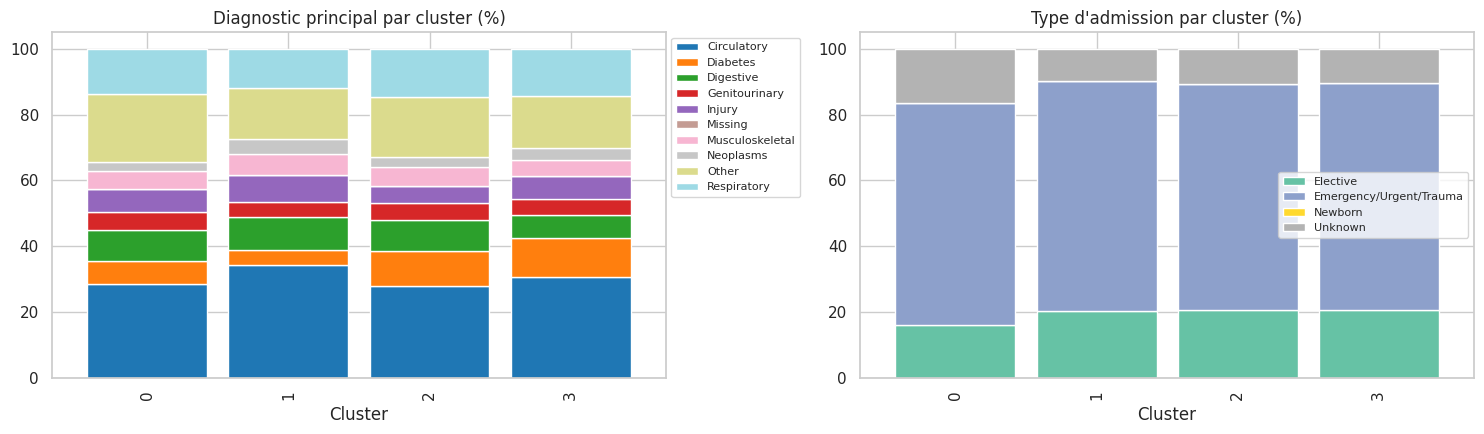

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
pd.crosstab(clean.cluster, clean.diag_1_group, normalize="index").mul(100).plot.bar(stacked=True, ax=axes[0], colormap="tab20", width=.85)
axes[0].set_title("Diagnostic principal par cluster (%)"); axes[0].legend(bbox_to_anchor=(1, 1), fontsize=8); axes[0].set_xlabel("Cluster")
pd.crosstab(clean.cluster, clean.admission_type, normalize="index").mul(100).plot.bar(stacked=True, ax=axes[1], colormap="Set2", width=.85)
axes[1].set_title("Type d'admission par cluster (%)"); axes[1].legend(fontsize=8); axes[1].set_xlabel("Cluster")
savefig("13_clusters_diag")

### 5.4 Interprétation des segments

| Cluster | Profil | Taille | % réadmis <30j |
|---|---|---|---|
| **0 — « Patients récurrents »** | Âgés (≈ 68 ans), **historique de visites lourd** (≈ 2,4 visites antérieures en moyenne), séjour moyen | 16 % | **12,2 %** |
| **1 — « Séjours lourds, traitement stable »** | Les plus âgés (≈ 70 ans), séjours longs (5,6 j), beaucoup d'actes et de médicaments, **aucun changement de traitement** | 32 % | 9,5 % |
| **2 — « Séjours courts et légers »** | Plus jeunes (≈ 60 ans), séjours courts (2,3 j), peu d'actes et de diagnostics | 32 % | **6,3 %** |
| **3 — « Séjours lourds, traitement intensifié »** | Séjours longs, **le plus de médicaments** (1,8) et de changements de dose (1,1) | 19 % | 9,9 % |

**Lecture.** Le taux de réadmission varie du simple au double entre le segment le plus léger (6,3 %) et celui des patients récurrents (12,2 %), et l'écart est statistiquement significatif (χ² = 370, p < 10⁻⁷⁰). Les segments retrouvent deux axes cliniques logiques : **la lourdeur du séjour** (durée, actes, médicaments) et **l'historique d'utilisation des soins**.

**Limite à signaler honnêtement.** La silhouette est faible (≈ 0,14) : les données forment un **continuum** plutôt que des groupes bien séparés, ce que montre aussi la projection ACP. Les segments sont donc une *partition utile pour décrire et prioriser*, pas des classes naturelles nettes. La stabilité est correcte (ARI ≈ 0,74 entre initialisations) ; le recoupement avec Ward est partiel (ARI ≈ 0,49), ce qui confirme que les frontières sont floues.

## 6. Classification : prédire la réadmission à moins de 30 jours

### 6.1 Protocole
- **Cible :** `readmit_30` (1 = réadmis sous 30 jours).
- **Variables :** celles de `FEATURES` — uniquement des informations connues à la sortie. Les identifiants, `readmitted` (cible d'origine) et le `cluster` sont exclus.
- **Découpage :** 80 % entraînement / 20 % test, **stratifié** pour conserver ~11 % de positifs. Un seul séjour par patient (§4.1) ⇒ aucune fuite entre train et test.
- **Prétraitement dans un `Pipeline`** (ajusté sur le train uniquement) : `log1p` + `StandardScaler` pour les numériques asymétriques, `StandardScaler` pour les autres, `OneHotEncoder` pour les catégorielles.
- **Déséquilibre :** pondération des classes (`class_weight="balanced"`) plutôt que sur-échantillonnage : on garde les données réelles intactes et on évite le risque de SMOTE de créer des profils cliniques artificiels.
- **Modèles comparés :** *Dummy* (référence), **Régression logistique** (interprétable), **Random Forest**, **Gradient Boosting** (`HistGradientBoostingClassifier`).

In [37]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              HistGradientBoostingClassifier, VotingClassifier)
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score, fbeta_score, recall_score, precision_score,
                             balanced_accuracy_score, matthews_corrcoef, confusion_matrix, roc_curve, precision_recall_curve,
                             ConfusionMatrixDisplay)

X = clean[FEATURES]; y = clean[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(f"Train : {X_train.shape} ({y_train.mean()*100:.2f} % positifs) | Test : {X_test.shape} ({y_test.mean()*100:.2f} % positifs)")

num_skew = [c for c in NUM_FEATS if c in SKEWED]
num_other = [c for c in NUM_FEATS if c not in SKEWED] + BIN_FEATS

def make_preprocessor(scale=True):
    log_pipe = Pipeline([("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")), ("sc", StandardScaler())]) if scale else FunctionTransformer(np.log1p, feature_names_out="one-to-one")
    other = StandardScaler() if scale else "passthrough"
    return ColumnTransformer([("num_log", log_pipe, num_skew), ("num", other, num_other),
                              ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=20), CAT_FEATS)])

# Poids de la classe positive (déséquilibre ~ 9 % de positifs) pour XGBoost / LightGBM
spw = (1 - y_train.mean()) / y_train.mean()

rf = RandomForestClassifier(n_estimators=200, min_samples_leaf=30, max_features="sqrt",
                            class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE)
hgb = HistGradientBoostingClassifier(learning_rate=0.05, max_depth=4, max_iter=300,
                                     l2_regularization=1.0, class_weight="balanced", random_state=RANDOM_STATE)
xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4, subsample=0.8, colsample_bytree=0.8,
                    min_child_weight=10, reg_lambda=1.0, scale_pos_weight=spw, eval_metric="logloss",
                    tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE)
lgbm = LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=15, max_depth=5, subsample=0.8, subsample_freq=1,
                      colsample_bytree=0.8, min_child_samples=50, reg_lambda=1.0, scale_pos_weight=spw,
                      n_jobs=-1, random_state=RANDOM_STATE, verbose=-1)

models = {
    "Régression logistique": Pipeline([("prep", make_preprocessor()), ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", C=0.1))]),
    "Random Forest":         Pipeline([("prep", make_preprocessor(scale=False)), ("clf", rf)]),
    "Extra Trees":           Pipeline([("prep", make_preprocessor(scale=False)),
                                       ("clf", ExtraTreesClassifier(n_estimators=300, min_samples_leaf=30, max_features="sqrt",
                                                                    class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE))]),
    "Gradient Boosting (HGB)": Pipeline([("prep", make_preprocessor(scale=False)), ("clf", hgb)]),
    "XGBoost":               Pipeline([("prep", make_preprocessor(scale=False)), ("clf", xgb)]),
    "LightGBM":              Pipeline([("prep", make_preprocessor(scale=False)), ("clf", lgbm)]),
    "MLP (réseau de neurones)": Pipeline([("prep", make_preprocessor()),
                                          ("clf", MLPClassifier(hidden_layer_sizes=(64, 32), alpha=1e-2, early_stopping=True,
                                                                validation_fraction=0.15, max_iter=200, random_state=RANDOM_STATE))]),
    "Ensemble (soft voting)": Pipeline([("prep", make_preprocessor(scale=False)),
                                        ("clf", VotingClassifier([("rf", rf), ("xgb", xgb), ("lgbm", lgbm)], voting="soft"))]),
}

Train : (55989, 40) (8.98 % positifs) | Test : (13998, 40) (8.98 % positifs)


### 6.2 Validation croisée (sur le jeu d'entraînement)
Validation croisée stratifiée à 5 plis, scorée en **ROC-AUC** et **PR-AUC** (*average precision*), plus robustes que l'accuracy sur une classe rare.

In [38]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name, mdl in models.items():
    s_auc = cross_val_score(mdl, X_train, y_train, cv=cv, scoring="roc_auc")
    s_ap  = cross_val_score(mdl, X_train, y_train, cv=cv, scoring="average_precision")
    cv_rows.append({"modèle": name, "ROC-AUC (moy)": s_auc.mean(), "± ": s_auc.std(), "PR-AUC (moy)": s_ap.mean(), "± ": s_ap.std()})
    print(name, "OK")
pd.DataFrame(cv_rows).set_index("modèle").round(4)

Régression logistique OK
Random Forest OK
Extra Trees OK
Gradient Boosting (HGB) OK
XGBoost OK
LightGBM OK
MLP (réseau de neurones) OK
Ensemble (soft voting) OK


,ROC-AUC (moy),±,PR-AUC (moy)
modèle,,,
Régression logistique,0.6381,0.0040,0.1505
Random Forest,0.6513,0.0050,0.1589
Extra Trees,0.6505,0.0049,0.1588
Gradient Boosting (HGB),0.6448,0.0061,0.1575
XGBoost,0.6440,0.0050,0.1601
LightGBM,0.6445,0.0039,0.1591
MLP (réseau de neurones),0.6301,0.0026,0.1445
Ensemble (soft voting),0.6500,0.0049,0.1613


### 6.3 Optimisation légère du meilleur modèle (Random Forest)
Recherche aléatoire d'hyperparamètres (8 combinaisons × 3 plis, métrique PR-AUC) : une recherche exhaustive serait coûteuse pour un gain marginal.

In [41]:
# 6.3 Optimisation du meilleur modèle (Random Forest)

param_dist = {
    "clf__n_estimators": [200, 300],
    "clf__min_samples_leaf": [20, 30, 50],
    "clf__max_features": ["sqrt", "log2"],
}

search = RandomizedSearchCV(
    models["Random Forest"],
    param_dist,
    n_iter=8,
    scoring="average_precision",
    cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1
)

search.fit(X_train, y_train)
print("Meilleurs hyperparamètres :", search.best_params_)
print(f"PR-AUC (CV) : {search.best_score_:.4f}")
models["Random Forest (optimisé)"] = search.best_estimator_

Meilleurs hyperparamètres : {'clf__n_estimators': 300, 'clf__min_samples_leaf': 20, 'clf__max_features': 'sqrt'}
PR-AUC (CV) : 0.1587


### 6.4 Évaluation sur le jeu de test
**Seuil de décision.** Par défaut, on classe « positif » si `P > 0,5`, ce qui est inadapté à un événement à 11 % : on choisit le seuil sur le **train** (prédictions de validation croisée, pour ne pas toucher au test) en maximisant le **score F2** (le rappel compte deux fois plus que la précision, cohérent avec le coût d'un faux négatif).

In [42]:
def best_threshold_f2(y_true, proba):
    prec, rec, thr = precision_recall_curve(y_true, proba)
    f2 = 5*prec[:-1]*rec[:-1] / (4*prec[:-1] + rec[:-1] + 1e-12)
    return thr[np.argmax(f2)]

results, probas, thresholds = [], {}, {}
for name, mdl in models.items():
    if name.startswith("Dummy"):
        mdl.fit(X_train, y_train); p_te = mdl.predict_proba(X_test)[:, 1]; thr = 0.5
    else:
        p_cv = cross_val_predict(mdl, X_train, y_train, cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE), method="predict_proba")[:, 1]
        thr = best_threshold_f2(y_train, p_cv)
        mdl.fit(X_train, y_train); p_te = mdl.predict_proba(X_test)[:, 1]
    probas[name], thresholds[name] = p_te, thr
    pred = (p_te >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    results.append({"modèle": name, "seuil": thr, "ROC-AUC": roc_auc_score(y_test, p_te), "PR-AUC": average_precision_score(y_test, p_te),
                    "Rappel": recall_score(y_test, pred), "Précision": precision_score(y_test, pred, zero_division=0),
                    "F1": f1_score(y_test, pred), "F2": fbeta_score(y_test, pred, beta=2), "Bal. accuracy": balanced_accuracy_score(y_test, pred),
                    "MCC": matthews_corrcoef(y_test, pred), "TP": tp, "FN": fn, "FP": fp, "TN": tn})
res_test = pd.DataFrame(results).set_index("modèle")
res_test.round(3)

,seuil,ROC-AUC,PR-AUC,Rappel,Précision,F1,F2,Bal. accuracy,MCC,TP,FN,FP,TN
modèle,,,,,,,,,,,,,
Régression logistique,0.408,0.645,0.155,0.796,0.109,0.192,0.352,0.578,0.093,1000,257,8158,4583
Random Forest,0.381,0.654,0.164,0.723,0.121,0.207,0.362,0.602,0.117,909,348,6609,6132
Extra Trees,0.387,0.654,0.168,0.788,0.110,0.193,0.352,0.578,0.094,990,267,8036,4705
Gradient Boosting (HGB),0.445,0.645,0.164,0.711,0.116,0.200,0.351,0.588,0.102,894,363,6810,5931
XGBoost,0.407,0.650,0.160,0.774,0.114,0.198,0.358,0.589,0.105,973,284,7587,5154
LightGBM,0.400,0.650,0.161,0.778,0.113,0.197,0.357,0.586,0.102,978,279,7710,5031
MLP (réseau de neurones),0.055,0.629,0.149,0.943,0.095,0.173,0.339,0.530,0.055,1185,72,11240,1501
Ensemble (soft voting),0.386,0.655,0.164,0.782,0.112,0.196,0.356,0.584,0.100,983,274,7814,4927
Random Forest (optimisé),0.354,0.653,0.164,0.713,0.121,0.206,0.360,0.600,0.115,896,361,6530,6211


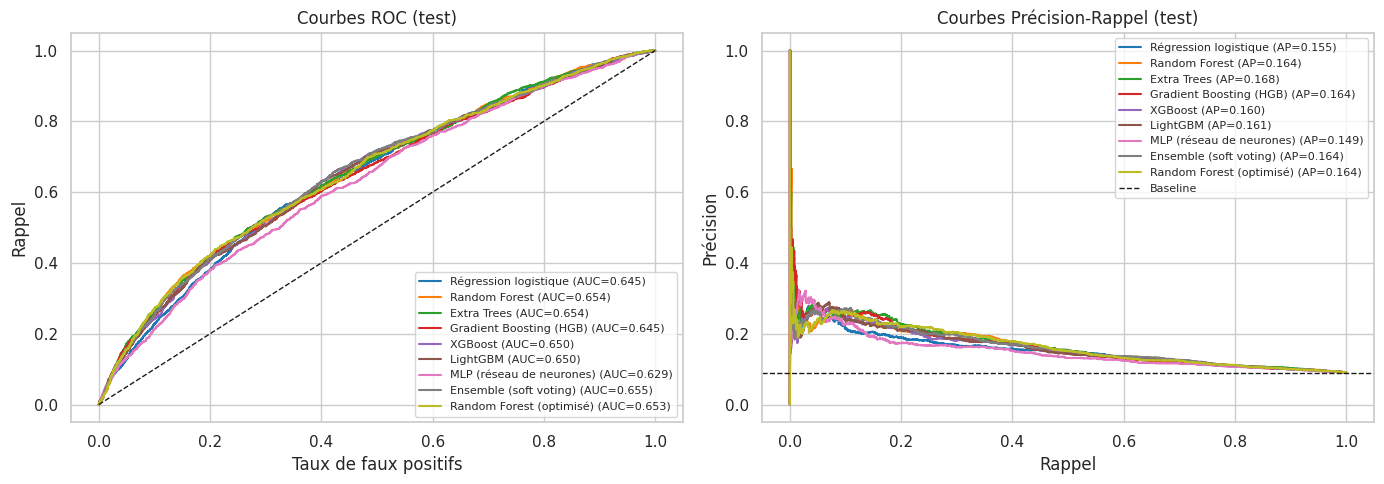

In [44]:
import matplotlib.pyplot as plt
palette = plt.cm.tab10(range(len(models)))
colors = dict(zip(models, ['#%02x%02x%02x' % tuple((c[:3]*255).astype(int)) for c in palette]))

# Puis votre code de courbes :
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, p in probas.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, p):.3f})", color=colors[name])
    pr, rc, _ = precision_recall_curve(y_test, p)
    axes[1].plot(rc, pr, label=f"{name} (AP={average_precision_score(y_test, p):.3f})", color=colors[name])

axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_title("Courbes ROC (test)")
axes[0].set_xlabel("Taux de faux positifs")
axes[0].set_ylabel("Rappel")
axes[0].legend(fontsize=8)

axes[1].axhline(y_test.mean(), color="k", ls="--", lw=1, label="Baseline")
axes[1].set_title("Courbes Précision-Rappel (test)")
axes[1].set_xlabel("Rappel")
axes[1].set_ylabel("Précision")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

Meilleur modèle (PR-AUC test) : Extra Trees


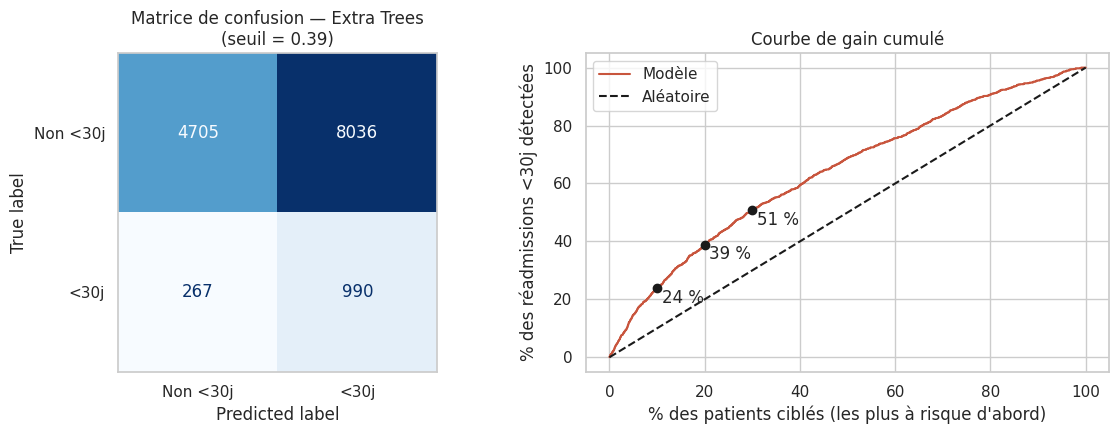

Lift dans le top 20 % : 1.95x


In [45]:
best_name = res_test.drop(index=[i for i in res_test.index if i.startswith("Dummy")])["PR-AUC"].idxmax()
print("Meilleur modèle (PR-AUC test) :", best_name)
best = models[best_name]; thr = thresholds[best_name]; p_best = probas[best_name]
pred = (p_best >= thr).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["Non <30j", "<30j"], cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title(f"Matrice de confusion — {best_name}\n(seuil = {thr:.2f})"); axes[0].grid(False)

# Courbe de gain : part des réadmissions captées en ciblant les x % de patients les plus à risque
order = np.argsort(-p_best); ys = y_test.values[order]
gain = np.cumsum(ys)/ys.sum(); pct = np.arange(1, len(ys)+1)/len(ys)
axes[1].plot(pct*100, gain*100, color="#C8553D", label="Modèle"); axes[1].plot([0, 100], [0, 100], "k--", label="Aléatoire")
for q in (0.1, 0.2, 0.3):
    g = gain[int(q*len(ys))-1]; axes[1].scatter(q*100, g*100, color="k", zorder=5); axes[1].annotate(f"{g*100:.0f} %", (q*100+1, g*100-5))
axes[1].set_xlabel("% des patients ciblés (les plus à risque d'abord)"); axes[1].set_ylabel("% des réadmissions <30j détectées"); axes[1].set_title("Courbe de gain cumulé"); axes[1].legend()
savefig("15_confusion_gain")
print(f"Lift dans le top 20 % : {gain[int(0.2*len(ys))-1]/0.2:.2f}x")

### 6.5 Interprétation : quelles variables comptent ?
Deux lectures complémentaires : **coefficients de la régression logistique** (effet direction/magnitude, en odds-ratio) et **importance par permutation** du meilleur modèle (baisse de ROC-AUC quand on mélange une variable ; calculée sur les variables d'origine, donc les modalités one-hot d'une même variable ne sont pas dispersées).

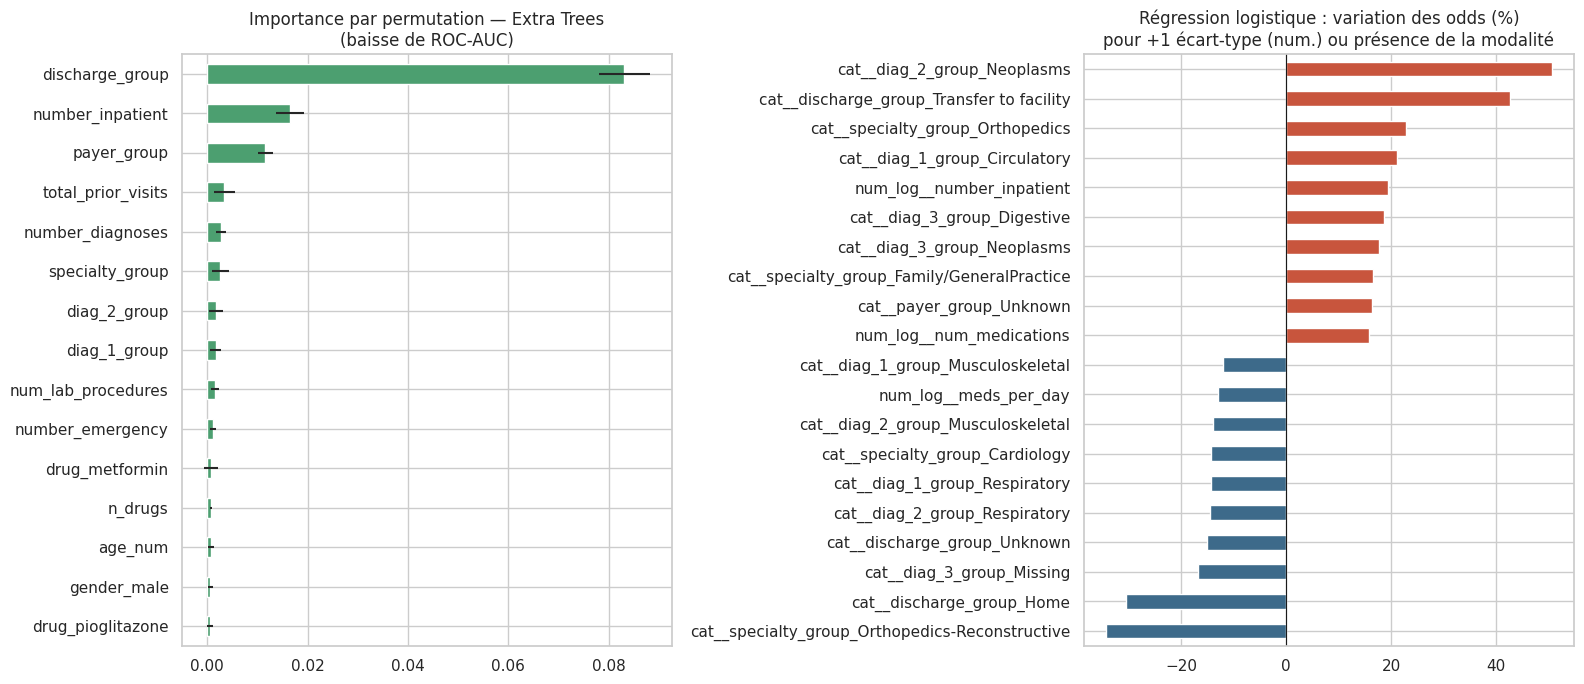

,baisse ROC-AUC
discharge_group,0.0831
number_inpatient,0.0164
payer_group,0.0116
total_prior_visits,0.0034
number_diagnoses,0.0028
specialty_group,0.0026
diag_2_group,0.0018
diag_1_group,0.0017
num_lab_procedures,0.0016
number_emergency,0.0011


In [46]:
from sklearn.inspection import permutation_importance
Xs = X_test.sample(6000, random_state=RANDOM_STATE); ys_ = y_test.loc[Xs.index]
pi = permutation_importance(best, Xs, ys_, scoring="roc_auc", n_repeats=5, random_state=RANDOM_STATE, n_jobs=1)
imp = pd.Series(pi.importances_mean, index=X.columns).sort_values(ascending=False)
err = pd.Series(pi.importances_std, index=X.columns)[imp.index]

lr = models["Régression logistique"]
coefs = pd.Series(lr.named_steps["clf"].coef_[0], index=lr.named_steps["prep"].get_feature_names_out())
top = pd.concat([coefs.nlargest(10), coefs.nsmallest(10)]).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
imp.head(15)[::-1].plot.barh(xerr=err.head(15)[::-1], color="#4C9F70", ax=axes[0]); axes[0].set_title(f"Importance par permutation — {best_name}\n(baisse de ROC-AUC)")
np.exp(top).sub(1).mul(100).plot.barh(color=np.where(top > 0, "#C8553D", "#3D6A8A"), ax=axes[1])
axes[1].set_title("Régression logistique : variation des odds (%)\npour +1 écart-type (num.) ou présence de la modalité"); axes[1].axvline(0, c="k", lw=.8)
savefig("16_importance")
imp.head(10).round(4).to_frame("baisse ROC-AUC")

### 6.6 Le segment (cluster) apporte-t-il de l'information supplémentaire ?
On ajoute le cluster comme variable catégorielle au meilleur modèle pour vérifier si la segmentation non supervisée enrichit la prédiction.

In [47]:
from sklearn.base import clone
Xc2 = clean[FEATURES + ["cluster"]].copy(); Xc2["cluster"] = Xc2["cluster"].astype(str)
Xtr2, Xte2 = Xc2.loc[X_train.index], Xc2.loc[X_test.index]
est = clone(best)
est.set_params(prep=ColumnTransformer(est.named_steps["prep"].transformers + [("cl", OneHotEncoder(handle_unknown="ignore"), ["cluster"])]))
est.fit(Xtr2, y_train); p2 = est.predict_proba(Xte2)[:, 1]
print(f"ROC-AUC sans cluster : {roc_auc_score(y_test, p_best):.4f} | avec cluster : {roc_auc_score(y_test, p2):.4f}")
print(f"PR-AUC  sans cluster : {average_precision_score(y_test, p_best):.4f} | avec cluster : {average_precision_score(y_test, p2):.4f}")

ROC-AUC sans cluster : 0.6538 | avec cluster : 0.6524
PR-AUC  sans cluster : 0.1678 | avec cluster : 0.1680


In [48]:
# Export du jeu « model-ready » (encodé + standardisé), plus un fichier de synthèse
prep_full = make_preprocessor(scale=True).fit(X)
Xm = prep_full.transform(X)
Xm = Xm.toarray() if hasattr(Xm, "toarray") else Xm
model_ready = pd.DataFrame(Xm, columns=prep_full.get_feature_names_out())
model_ready[TARGET] = y.values
model_ready.to_csv(os.path.join(OUT_DIR, "diabetic_data_model_ready.csv"), index=False)
print("Fichiers exportés :", "diabetic_data_clean.csv", clean.shape, "| diabetic_data_model_ready.csv", model_ready.shape)

Fichiers exportés : diabetic_data_clean.csv (69987, 45) | diabetic_data_model_ready.csv (69987, 107)


## 7. Évaluation et interprétation des résultats



- **Les modèles battent nettement le hasard** (ROC-AUC ≈ 0,65 contre 0,50 ; PR-AUC ≈ 0,16 contre 0,09 de prévalence), mais restent **modestes**. Les écarts entre modèles (≈ 0,01 d'AUC) sont du même ordre que l'écart-type de la validation croisée (≈ 0,005) : **aucun modèle n'est clairement supérieur**. Un modèle plus complexe n'apporte pas de gain réel ; la régression logistique, plus interprétable, est un choix défendable.
- **Précision faible :** au seuil retenu (priorité au rappel), environ **1 alerte sur 8** est un vrai positif (≈ 12 % contre 9 % au hasard). Le Random Forest détecte ~72 % des réadmissions, au prix de nombreuses fausses alertes (≈ 6 600 sur ≈ 12 700 patients non réadmis).
- **Intérêt opérationnel :** cibler les 20 % de patients les plus à risque permet de capter environ **40 % des réadmissions** (lift ≈ 2×, cf. courbe de gain). C'est un outil de *priorisation* pour un hôpital aux ressources limitées, pas un outil de décision individuelle.
- Ce niveau de performance est **cohérent avec ce que l'on observe habituellement sur ce dataset** (AUC de l'ordre de 0,6-0,7) : la réadmission dépend de facteurs absents des données (suivi après sortie, environnement social, observance).

### 7.1 Variables déterminantes
- La **destination à la sortie** (`discharge_group`) est de loin la plus informative (baisse d'AUC ≈ 0,07 par permutation) : transfert vers un établissement ≈ 15 % de réadmission contre ≈ 7 % pour un retour à domicile.
- Viennent ensuite l'**historique d'hospitalisations** (`number_inpatient`, `total_prior_visits`), le **type d'assurance** (`payer_group`) et le **nombre de diagnostics**.
- Attention : `payer_group` peut servir de *proxy* socio-économique ; son usage dans un outil réel soulève des questions d'équité.

### 7.2 Apport de la segmentation à la classification
Ajouter le cluster comme variable ne change pas les performances (ROC-AUC 0,6537 → 0,6536) : l'information des segments est **déjà contenue** dans les variables dont ils sont issus. Le clustering garde son utilité **descriptive** (profils lisibles pour des équipes cliniques) plutôt que prédictive.

## 8. Conclusion, limites et pistes

**Ce qui a été fait.** 101 766 séjours ont été nettoyés (11 problèmes de qualité traités et justifiés), réduits à 69 987 patients uniques et enrichis de variables dérivées. Le fichier nettoyé (`diabetic_data_clean.csv`, 44 colonnes, sans valeur manquante) et sa version encodée/standardisée (`diabetic_data_model_ready.csv`) sont fournis.

**Résultats clés.** (1) 4 profils de séjours dont le risque de réadmission va de 6 % à 12 % ; (2) un modèle à ROC-AUC ≈ 0,65 permettant de capter ~40 % des réadmissions en ciblant 20 % des patients.

**Limites.**
- Signal intrinsèquement faible : des facteurs importants sont absents des données.
- Le **premier séjour par patient** réduit les données et change la prévalence (9 % contre 11 %).
- Silhouette faible : les segments ne sont pas des groupes naturels séparés.
- Données de 1999-2008 : pratiques et codage (CIM-9) ont évolué.
- Seuil choisi pour maximiser F2 : un autre arbitrage coût/bénéfice donnerait un autre seuil.
- Modèles pondérés : leurs probabilités ne sont pas calibrées.

**Pistes d'amélioration.** Calibration des probabilités, modèles de survie sur le délai de réadmission, utilisation de codes CIM-9 plus détaillés avec réduction de dimension, prise en compte des séjours multiples via `GroupKFold`, analyse d'équité par sous-groupe (race, assurance).